# Smooth Manifolds and Tangent Spaces
## Charts, Tangent Vectors, and Pushforwards — With Applications to Configuration Spaces in Robotics

This notebook develops the **abstract theory of smooth manifolds** from first principles — charts and atlases, tangent vectors (via curves and derivations), the pushforward/differential of smooth maps, tangent bundles, vector fields and flows, and pullbacks. Every definition is made concrete through computation and visualization.

**What you'll learn:**
1. Coordinate charts and atlases with smooth transition maps
2. Two definitions of tangent vectors (equivalence classes of curves, derivations) and their equivalence
3. The pushforward (differential) of smooth maps — connecting to Jacobians
4. The tangent bundle as a manifold — connecting to phase space
5. Vector fields and flows on manifolds
6. Application: configuration spaces of robot arms as product manifolds

**Prerequisites:** Multivariable calculus, linear algebra, basic topology (open sets, continuity). Helpful: the [Differential Geometry notebook](../differential_geometry.ipynb) and the [Lie Groups notebook](../../linear-algebra/lie-groups/lie_groups.ipynb).

**References:**
- Lee, J.M. *Introduction to Smooth Manifolds*, 2nd ed., Springer, 2013.
- Tu, L.W. *An Introduction to Manifolds*, 2nd ed., Springer, 2011.
- Murray, Li & Sastry, *A Mathematical Introduction to Robotic Manipulation*, CRC Press, 1994.

**See also:** [Matrix Manifolds](../../linear-algebra/matrix-manifolds/matrix_manifolds.ipynb) (optimization on Stiefel/Grassmann manifolds), [Information Geometry](../../probability/information-geometry/information_geometry.ipynb) (Fisher metric on statistical manifolds).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.integrate import solve_ivp
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d.proj3d import proj_transform

%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

np.random.seed(42)

In [2]:
# =============================================================================
# Global Constants
# =============================================================================

EPS = 1e-7                 # Finite difference step size
TOL = 1e-5                 # Numerical tolerance for verification
N_POINTS = 500             # Default discretization

# Link lengths for robot arm examples
L1, L2, L3 = 1.0, 0.8, 0.6

# Colors
C_BLUE = 'steelblue'
C_RED = 'coral'
C_GREEN = 'seagreen'
C_GOLD = 'goldenrod'
C_PURPLE = 'mediumpurple'
C_GRAY = 'gray'

---
## 1. Why Abstract Manifolds?

Consider a **2-link planar robot arm** with joint angles $\theta_1, \theta_2 \in [0, 2\pi)$. The **configuration space** — the set of all possible states — is the torus $T^2 = S^1 \times S^1$. This is *not* a subset of $\mathbb{R}^2$: the angles wrap around.

**The wrapping problem:** Suppose we want to interpolate between configurations $\theta = 0.1$ and $\theta = 6.18$ (just past $2\pi$). A naive linear interpolation in $\mathbb{R}$ traverses $\Delta\theta \approx 6.08$ — nearly the entire circle — instead of the short arc of length $\approx 0.2$.

| Approach | Problem |
|----------|---------|
| Single global coordinate ($\theta \in \mathbb{R}$) | Singularities at $0 \sim 2\pi$; interpolation fails |
| Embedding in $\mathbb{R}^2$ ($\cos\theta, \sin\theta$) | Wasteful (2 coords for 1 DOF); constraints needed |
| **Charts + Atlas** | Local coordinates, globally consistent |

This motivates the central idea: describe spaces using **local coordinate patches (charts)** that overlap smoothly, rather than a single global coordinate system.

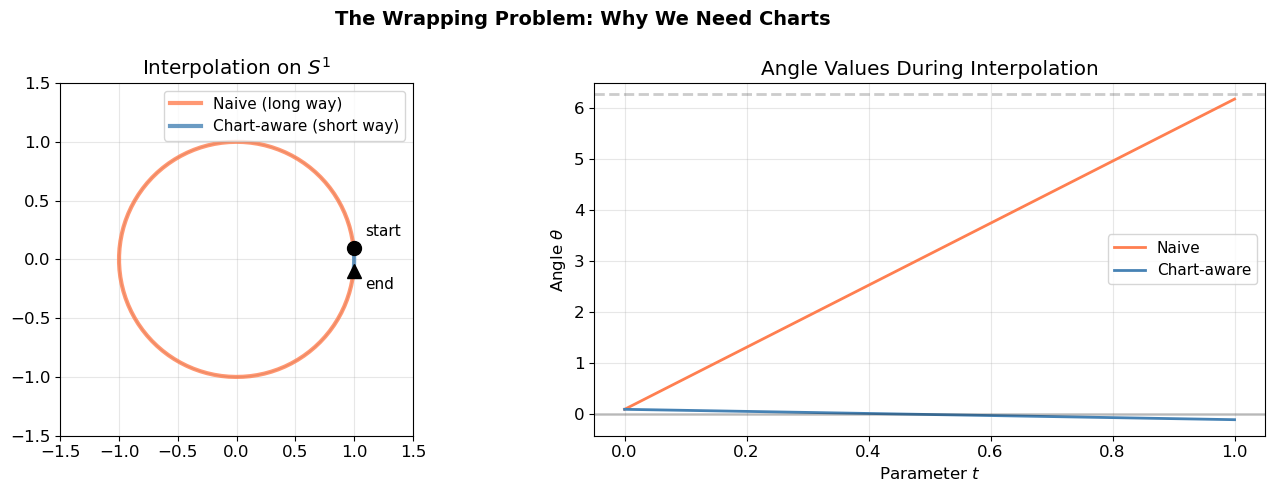

Naive arc length:  6.080 rad
Proper arc length: 0.203 rad
Proper interpolation takes shorter arc: [PASS]


In [3]:
def angle_interpolate_naive(a, b, t):
    """Linear interpolation in R -- ignores angle wrapping."""
    return (1 - t) * a + t * b

def angle_interpolate_proper(a, b, t):
    """Interpolation on S^1 -- takes the shorter arc."""
    diff = (b - a) % (2 * np.pi)
    if diff > np.pi:
        diff -= 2 * np.pi
    return a + t * diff

# Demonstrate the wrapping problem
a, b = 0.1, 6.18  # b is just past 2*pi, close to a on the circle
t_vals = np.linspace(0, 1, 100)

naive_interp = np.array([angle_interpolate_naive(a, b, t) for t in t_vals])
proper_interp = np.array([angle_interpolate_proper(a, b, t) for t in t_vals])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: interpolations on the circle
ax = axes[0]
theta_circle = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.cos(theta_circle), np.sin(theta_circle), 'k-', alpha=0.3, linewidth=1)
ax.plot(np.cos(naive_interp), np.sin(naive_interp), '-', color=C_RED, linewidth=3,
        label='Naive (long way)', alpha=0.8)
ax.plot(np.cos(proper_interp), np.sin(proper_interp), '-', color=C_BLUE, linewidth=3,
        label='Chart-aware (short way)', alpha=0.8)
ax.plot(np.cos(a), np.sin(a), 'ko', markersize=10, zorder=5)
ax.plot(np.cos(b), np.sin(b), 'k^', markersize=10, zorder=5)
ax.annotate('start', (np.cos(a) + 0.1, np.sin(a) + 0.1), fontsize=11)
ax.annotate('end', (np.cos(b) + 0.1, np.sin(b) - 0.15), fontsize=11)
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal')
ax.legend(fontsize=11)
ax.set_title('Interpolation on $S^1$')

# Right: angle values vs parameter t
ax = axes[1]
ax.plot(t_vals, naive_interp, color=C_RED, linewidth=2, label='Naive')
ax.plot(t_vals, proper_interp, color=C_BLUE, linewidth=2, label='Chart-aware')
ax.axhline(0, color='k', alpha=0.2); ax.axhline(2 * np.pi, color='k', alpha=0.2, linestyle='--')
ax.set_xlabel('Parameter $t$')
ax.set_ylabel('Angle $\\theta$')
ax.set_title('Angle Values During Interpolation')
ax.legend(fontsize=11)

plt.suptitle('The Wrapping Problem: Why We Need Charts', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Verify: proper interpolation always takes shorter arc
arc_naive = abs(naive_interp[-1] - naive_interp[0])
arc_proper = abs(proper_interp[-1] - proper_interp[0])
status = "PASS" if arc_proper < arc_naive else "FAIL"
print(f"Naive arc length:  {arc_naive:.3f} rad")
print(f"Proper arc length: {arc_proper:.3f} rad")
print(f"Proper interpolation takes shorter arc: [{status}]")

---
## 2. Topological and Smooth Manifolds

### Definitions

A **topological manifold** of dimension $n$ is a Hausdorff, second-countable topological space $M$ such that every point has a neighborhood homeomorphic to an open subset of $\mathbb{R}^n$.

A **chart** on $M$ is a pair $(U, \varphi)$ where $U \subseteq M$ is open and $\varphi: U \to \varphi(U) \subseteq \mathbb{R}^n$ is a homeomorphism.

An **atlas** is a collection of charts $\{(U_\alpha, \varphi_\alpha)\}$ that covers $M$: $\bigcup_\alpha U_\alpha = M$.

For overlapping charts $(U_\alpha, \varphi_\alpha)$ and $(U_\beta, \varphi_\beta)$, the **transition function** is:

$$\tau_{\beta\alpha} = \varphi_\beta \circ \varphi_\alpha^{-1} : \varphi_\alpha(U_\alpha \cap U_\beta) \to \varphi_\beta(U_\alpha \cap U_\beta)$$

A **smooth manifold** is a topological manifold equipped with an atlas whose transition functions are all $C^\infty$.

### Intuition

Think of charts as **local coordinate systems**. Just as a world atlas uses multiple flat maps to cover the globe (with overlap regions where maps agree), a smooth manifold uses multiple coordinate patches. The transition functions describe how to convert between coordinate systems in the overlap.

In [4]:
# =============================================================================
# Chart and Atlas classes
# =============================================================================

class Chart:
    """A coordinate chart (U, phi) on a manifold.

    Attributes:
        name: Human-readable name.
        phi: Map from manifold point (in ambient coords) to chart coords.
        phi_inv: Inverse map from chart coords to ambient coords.
        in_domain: Returns True if a manifold point is in the chart domain U.
        dim: Dimension of the chart (= dimension of the manifold).
    """
    def __init__(self, name, phi, phi_inv, in_domain, dim):
        self.name = name
        self.phi = phi
        self.phi_inv = phi_inv
        self.in_domain = in_domain
        self.dim = dim

    def __repr__(self):
        return f"Chart('{self.name}', dim={self.dim})"


class Atlas:
    """A smooth atlas: collection of compatible charts.

    Attributes:
        charts: List of Chart objects.
        name: Name of the manifold.
    """
    def __init__(self, name, charts):
        self.name = name
        self.charts = charts

    def transition(self, chart_a, chart_b, coords_a):
        """Compute transition function: phi_b . phi_a^{-1}(coords_a)."""
        p = chart_a.phi_inv(coords_a)    # ambient point
        return chart_b.phi(p)            # new chart coords

    def transition_jacobian(self, chart_a, chart_b, coords_a, eps=EPS):
        """Numerical Jacobian of the transition function tau_{ba}."""
        n = chart_a.dim
        J = np.zeros((n, n))
        coords_a = np.atleast_1d(np.array(coords_a, dtype=float))
        f0 = np.atleast_1d(self.transition(chart_a, chart_b, coords_a))
        for i in range(n):
            e = np.zeros(n)
            e[i] = eps
            fp = np.atleast_1d(self.transition(chart_a, chart_b, coords_a + e))
            fm = np.atleast_1d(self.transition(chart_a, chart_b, coords_a - e))
            J[:, i] = (fp - fm) / (2 * eps)
        return J

    def find_chart(self, p):
        """Find the first chart whose domain contains the point p."""
        for c in self.charts:
            if c.in_domain(p):
                return c
        raise ValueError(f"No chart contains point {p}")

    def __repr__(self):
        return f"Atlas('{self.name}', {len(self.charts)} charts)"

### Example 1: The Circle $S^1$

$S^1 = \{(x, y) \in \mathbb{R}^2 : x^2 + y^2 = 1\}$ is a 1-dimensional manifold. We use **stereographic projection** to build an atlas of two charts:

- **North chart** $\varphi_N$: project from the north pole $(0, 1)$ onto the $x$-axis. For $(x, y) \neq (0, 1)$:
$$\varphi_N(x, y) = \frac{x}{1 - y}$$

- **South chart** $\varphi_S$: project from the south pole $(0, -1)$. For $(x, y) \neq (0, -1)$:
$$\varphi_S(x, y) = \frac{x}{1 + y}$$

The **transition function** on the overlap (all of $S^1$ except both poles):
$$\tau_{SN}(t) = \varphi_S \circ \varphi_N^{-1}(t) = \frac{1}{t}$$

This is smooth on $\mathbb{R} \setminus \{0\}$, confirming $S^1$ is a smooth manifold.

In [5]:
# =============================================================================
# S^1: Stereographic atlas
# =============================================================================

# North chart: project from (0, 1)
S1_north = Chart(
    name='S1_stereo_north',
    phi=lambda p: np.array([p[0] / (1 - p[1])]),
    phi_inv=lambda t: (lambda s=np.atleast_1d(t)[0]: np.array([2*s/(1+s**2), (s**2-1)/(1+s**2)]))(),
    in_domain=lambda p: p[1] < 0.999,  # everywhere except north pole
    dim=1,
)

# South chart: project from (0, -1)
S1_south = Chart(
    name='S1_stereo_south',
    phi=lambda p: np.array([p[0] / (1 + p[1])]),
    phi_inv=lambda t: (lambda s=np.atleast_1d(t)[0]: np.array([2*s/(1+s**2), (1-s**2)/(1+s**2)]))(),
    in_domain=lambda p: p[1] > -0.999,  # everywhere except south pole
    dim=1,
)

S1_atlas = Atlas('S^1', [S1_north, S1_south])

# ---- Verify round-trip consistency ----
print("=== S^1 Stereographic Atlas ===\n")
test_angles = [np.pi/6, np.pi/2, np.pi, 3*np.pi/2, 5*np.pi/3]
all_pass = True
for theta in test_angles:
    p = np.array([np.cos(theta), np.sin(theta)])
    for chart in S1_atlas.charts:
        if chart.in_domain(p):
            coords = chart.phi(p)
            p_back = chart.phi_inv(coords)
            err = np.linalg.norm(p - p_back)
            ok = err < TOL
            all_pass &= ok
            print(f"  theta={theta:.2f}, {chart.name}: coords={coords[0]:.4f}, "
                  f"round-trip error={err:.2e} [{'PASS' if ok else 'FAIL'}]")

# Verify transition function = 1/t
print("\n--- Transition function tau_SN(t) = 1/t ---")
for t_test in [0.5, 1.0, 2.0, -1.5]:
    t_arr = np.array([t_test])
    tau = S1_atlas.transition(S1_north, S1_south, t_arr)
    expected = 1.0 / t_test
    err = abs(tau[0] - expected)
    ok = err < TOL
    all_pass &= ok
    print(f"  t={t_test:6.2f}: tau_SN={tau[0]:.6f}, 1/t={expected:.6f}, err={err:.2e} [{'PASS' if ok else 'FAIL'}]")

# Verify transition is its own inverse: tau_NS(tau_SN(t)) = t
print("\n--- Involutory: tau_NS . tau_SN = id ---")
for t_test in [0.3, -2.0, 5.0]:
    t_arr = np.array([t_test])
    rt = S1_atlas.transition(S1_south, S1_north,
                              S1_atlas.transition(S1_north, S1_south, t_arr))
    err = abs(rt[0] - t_test)
    ok = err < TOL
    all_pass &= ok
    print(f"  t={t_test}: round-trip={rt[0]:.6f}, err={err:.2e} [{'PASS' if ok else 'FAIL'}]")

print(f"\nAll S^1 checks: [{'PASS' if all_pass else 'FAIL'}]")

=== S^1 Stereographic Atlas ===

  theta=0.52, S1_stereo_north: coords=1.7321, round-trip error=1.67e-16 [PASS]
  theta=0.52, S1_stereo_south: coords=0.5774, round-trip error=1.11e-16 [PASS]
  theta=1.57, S1_stereo_south: coords=0.0000, round-trip error=0.00e+00 [PASS]
  theta=3.14, S1_stereo_north: coords=-1.0000, round-trip error=9.96e-17 [PASS]
  theta=3.14, S1_stereo_south: coords=-1.0000, round-trip error=9.96e-17 [PASS]
  theta=4.71, S1_stereo_north: coords=-0.0000, round-trip error=0.00e+00 [PASS]
  theta=5.24, S1_stereo_north: coords=0.2679, round-trip error=0.00e+00 [PASS]
  theta=5.24, S1_stereo_south: coords=3.7321, round-trip error=0.00e+00 [PASS]

--- Transition function tau_SN(t) = 1/t ---
  t=  0.50: tau_SN=2.000000, 1/t=2.000000, err=0.00e+00 [PASS]
  t=  1.00: tau_SN=1.000000, 1/t=1.000000, err=0.00e+00 [PASS]
  t=  2.00: tau_SN=0.500000, 1/t=0.500000, err=0.00e+00 [PASS]
  t= -1.50: tau_SN=-0.666667, 1/t=-0.666667, err=1.11e-16 [PASS]

--- Involutory: tau_NS . tau_SN 

### Example 2: The Sphere $S^2$

$S^2 = \{(x, y, z) \in \mathbb{R}^3 : x^2 + y^2 + z^2 = 1\}$ is a 2-dimensional manifold. Again using stereographic projection:

- **North chart** $\varphi_N$: project from $(0, 0, 1)$ onto the $xy$-plane:
$$\varphi_N(x, y, z) = \left(\frac{x}{1 - z}, \frac{y}{1 - z}\right)$$

- **South chart** $\varphi_S$: project from $(0, 0, -1)$:
$$\varphi_S(x, y, z) = \left(\frac{x}{1 + z}, \frac{y}{1 + z}\right)$$

The transition function is the **inversion map**:
$$\tau_{SN}(u, v) = \frac{(u, v)}{u^2 + v^2}$$

This is smooth on $\mathbb{R}^2 \setminus \{0\}$ and is a **conformal** map (preserves angles).

In [6]:
# =============================================================================
# S^2: Stereographic atlas
# =============================================================================

def _S2_stereo_north_inv(uv):
    u, v = uv[0], uv[1]
    r2 = u**2 + v**2
    return np.array([2*u/(1+r2), 2*v/(1+r2), (r2-1)/(1+r2)])

def _S2_stereo_south_inv(uv):
    u, v = uv[0], uv[1]
    r2 = u**2 + v**2
    return np.array([2*u/(1+r2), 2*v/(1+r2), (1-r2)/(1+r2)])

S2_north = Chart(
    name='S2_stereo_north',
    phi=lambda p: np.array([p[0]/(1-p[2]), p[1]/(1-p[2])]),
    phi_inv=_S2_stereo_north_inv,
    in_domain=lambda p: p[2] < 0.999,
    dim=2,
)

S2_south = Chart(
    name='S2_stereo_south',
    phi=lambda p: np.array([p[0]/(1+p[2]), p[1]/(1+p[2])]),
    phi_inv=_S2_stereo_south_inv,
    in_domain=lambda p: p[2] > -0.999,
    dim=2,
)

S2_atlas = Atlas('S^2', [S2_north, S2_south])

# ---- Verify S^2 atlas ----
print("=== S^2 Stereographic Atlas ===\n")
test_points_S2 = [
    np.array([1, 0, 0]),
    np.array([0, 1, 0]),
    np.array([0, 0, -1 + 0.01]),  # near south pole
    np.array([1/np.sqrt(3), 1/np.sqrt(3), 1/np.sqrt(3)]),
]

all_pass = True
for p in test_points_S2:
    p = p / np.linalg.norm(p)  # ensure on S^2
    for chart in S2_atlas.charts:
        if chart.in_domain(p):
            coords = chart.phi(p)
            p_back = chart.phi_inv(coords)
            err = np.linalg.norm(p - p_back)
            ok = err < TOL
            all_pass &= ok

print("Round-trip checks: all passed" if all_pass else "SOME FAILED")

# Verify transition = inversion
print("\n--- Transition tau_SN(u,v) = (u,v)/(u^2+v^2) ---")
for uv in [np.array([1.0, 0.0]), np.array([0.5, 0.5]), np.array([-1.0, 2.0])]:
    tau = S2_atlas.transition(S2_north, S2_south, uv)
    expected = uv / np.dot(uv, uv)
    err = np.linalg.norm(tau - expected)
    ok = err < TOL
    all_pass &= ok
    print(f"  ({uv[0]:.1f},{uv[1]:.1f}) -> ({tau[0]:.4f},{tau[1]:.4f}), "
          f"expected ({expected[0]:.4f},{expected[1]:.4f}), err={err:.2e} [{'PASS' if ok else 'FAIL'}]")

# Verify Jacobian of transition is nonsingular
print("\n--- Transition Jacobian nonsingularity ---")
for uv in [np.array([1.0, 0.5]), np.array([0.3, -0.7])]:
    J = S2_atlas.transition_jacobian(S2_north, S2_south, uv)
    det_J = np.linalg.det(J)
    ok = abs(det_J) > 1e-8
    all_pass &= ok
    print(f"  at ({uv[0]:.1f},{uv[1]:.1f}): det(J) = {det_J:.6f} [{'PASS' if ok else 'FAIL'}]")

print(f"\nAll S^2 checks: [{'PASS' if all_pass else 'FAIL'}]")

=== S^2 Stereographic Atlas ===

Round-trip checks: all passed

--- Transition tau_SN(u,v) = (u,v)/(u^2+v^2) ---
  (1.0,0.0) -> (1.0000,0.0000), expected (1.0000,0.0000), err=0.00e+00 [PASS]
  (0.5,0.5) -> (1.0000,1.0000), expected (1.0000,1.0000), err=1.57e-16 [PASS]
  (-1.0,2.0) -> (-0.2000,0.4000), expected (-0.2000,0.4000), err=0.00e+00 [PASS]

--- Transition Jacobian nonsingularity ---
  at (1.0,0.5): det(J) = -0.640000 [PASS]
  at (0.3,-0.7): det(J) = -2.972652 [PASS]

All S^2 checks: [PASS]


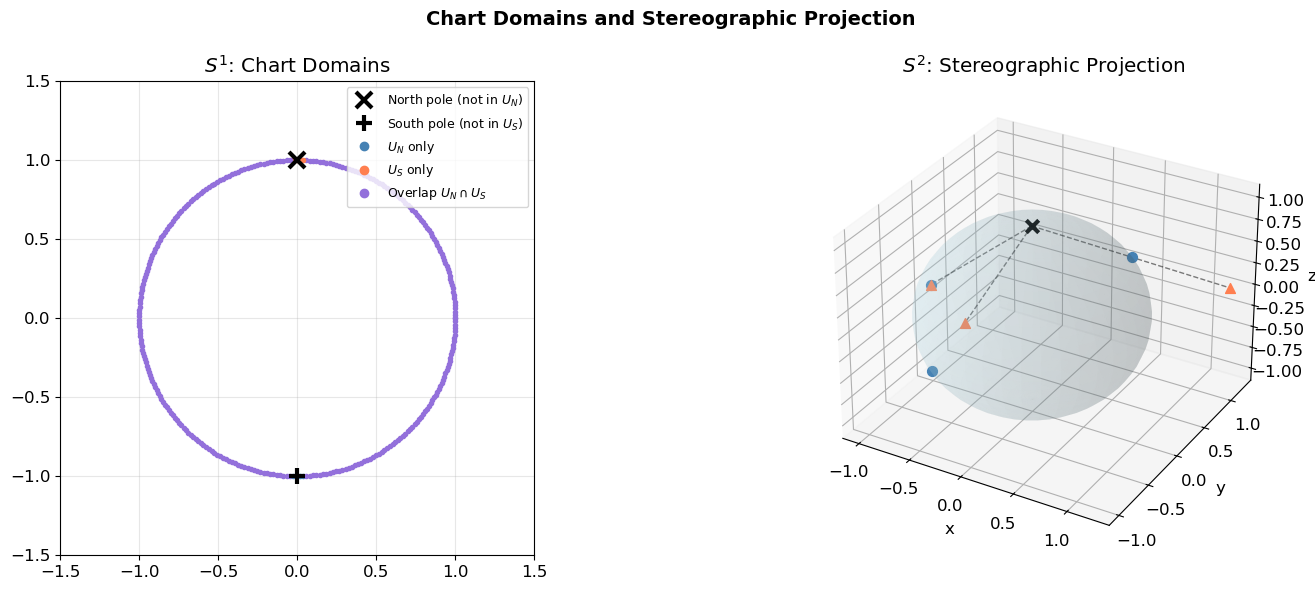

In [7]:
# ---- Visualize stereographic projection and chart domains ----
fig = plt.figure(figsize=(16, 6))

# Left: S^1 charts
ax1 = fig.add_subplot(1, 2, 1)
theta = np.linspace(0, 2 * np.pi, 300)

# Color points by which chart(s) they belong to
for i, th in enumerate(theta):
    p = np.array([np.cos(th), np.sin(th)])
    in_N = S1_north.in_domain(p)
    in_S = S1_south.in_domain(p)
    if in_N and in_S:
        color = C_PURPLE   # overlap
    elif in_N:
        color = C_BLUE
    else:
        color = C_RED
    ax1.plot(np.cos(th), np.sin(th), 'o', color=color, markersize=3)

ax1.plot(0, 1, 'kx', markersize=12, markeredgewidth=3, label='North pole (not in $U_N$)')
ax1.plot(0, -1, 'k+', markersize=12, markeredgewidth=3, label='South pole (not in $U_S$)')
ax1.plot([], [], 'o', color=C_BLUE, label='$U_N$ only')
ax1.plot([], [], 'o', color=C_RED, label='$U_S$ only')
ax1.plot([], [], 'o', color=C_PURPLE, label='Overlap $U_N \\cap U_S$')
ax1.set_xlim(-1.5, 1.5); ax1.set_ylim(-1.5, 1.5)
ax1.set_aspect('equal')
ax1.legend(fontsize=9, loc='upper right')
ax1.set_title('$S^1$: Chart Domains')

# Right: S^2 stereographic projection diagram
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# Draw sphere wireframe
u_w = np.linspace(0, np.pi, 30)
v_w = np.linspace(0, 2 * np.pi, 40)
Uw, Vw = np.meshgrid(u_w, v_w)
X_s = np.sin(Uw) * np.cos(Vw)
Y_s = np.sin(Uw) * np.sin(Vw)
Z_s = np.cos(Uw)
ax2.plot_surface(X_s, Y_s, Z_s, alpha=0.15, color='lightblue', edgecolor='none')

# Show projection lines from north pole to a few points
north = np.array([0, 0, 1])
sample_angles = [(np.pi/3, np.pi/4), (np.pi/2, np.pi), (2*np.pi/3, 5*np.pi/4)]
for u0, v0 in sample_angles:
    p = np.array([np.sin(u0)*np.cos(v0), np.sin(u0)*np.sin(v0), np.cos(u0)])
    proj = S2_north.phi(p)
    plane_pt = np.array([proj[0], proj[1], 0])  # projected point on z=0 plane

    # Draw line from north pole through p to plane
    ax2.plot([north[0], plane_pt[0]], [north[1], plane_pt[1]], [north[2], plane_pt[2]],
             'k--', alpha=0.5, linewidth=1)
    ax2.scatter(*p, color=C_BLUE, s=50, zorder=5)
    ax2.scatter(*plane_pt, color=C_RED, s=50, marker='^', zorder=5)

ax2.scatter(0, 0, 1, color='k', s=80, marker='x', linewidths=3, label='North pole')
ax2.set_title('$S^2$: Stereographic Projection')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')

plt.suptitle('Chart Domains and Stereographic Projection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Tangent Vectors via Equivalence Classes of Curves

How do we define "velocity" or "direction" at a point on a manifold? We cannot simply subtract points (a manifold is not a vector space). Instead, we use **curves passing through the point**.

### Definition

A **smooth curve** through $p \in M$ is a smooth map $\gamma: (-\varepsilon, \varepsilon) \to M$ with $\gamma(0) = p$.

Two curves $\gamma_1, \gamma_2$ through $p$ are **equivalent** ($\gamma_1 \sim \gamma_2$) if, for some chart $(U, \varphi)$ around $p$:

$$(\varphi \circ \gamma_1)'(0) = (\varphi \circ \gamma_2)'(0)$$

A **tangent vector** at $p$ is an equivalence class $[\gamma]$. The **tangent space** $T_pM$ is the set of all tangent vectors at $p$. It is a vector space of dimension $n = \dim M$.

### Coordinate representation

In a chart $(U, \varphi)$ with coordinates $(x^1, \ldots, x^n)$, a tangent vector $v = [\gamma]$ is represented by:

$$v_\varphi = (\varphi \circ \gamma)'(0) \in \mathbb{R}^n$$

### Change of chart (transformation law)

If $v_\alpha = (\varphi_\alpha \circ \gamma)'(0)$ and $v_\beta = (\varphi_\beta \circ \gamma)'(0)$, then:

$$v_\beta = J_{\beta\alpha} \cdot v_\alpha$$

where $J_{\beta\alpha} = D(\tau_{\beta\alpha})_{\varphi_\alpha(p)}$ is the **Jacobian of the transition function** at $\varphi_\alpha(p)$.

This is the fundamental **transformation law for tangent vectors**: they transform by the Jacobian of the coordinate change.

In [8]:
# =============================================================================
# Tangent vectors via curves
# =============================================================================

def tangent_vector_via_curve(curve_func, chart, t=0, dt=EPS):
    """Compute tangent vector of a curve in a given chart.

    Returns (phi . gamma)'(0) via central finite difference.

    Args:
        curve_func: gamma(t) -> point on manifold (ambient coords). Callable.
        chart: Chart object with phi map.
        t: Parameter value (default 0).
        dt: Finite difference step.

    Returns:
        v: Tangent vector in chart coordinates. Shape: (dim,).
    """
    p_plus = curve_func(t + dt)
    p_minus = curve_func(t - dt)
    coords_plus = chart.phi(p_plus)
    coords_minus = chart.phi(p_minus)
    return (coords_plus - coords_minus) / (2 * dt)


def tangent_vector_ambient(curve_func, t=0, dt=EPS):
    """Compute tangent vector in ambient (embedding) coordinates.

    Returns gamma'(0) via central finite difference.
    """
    return (curve_func(t + dt) - curve_func(t - dt)) / (2 * dt)


def tangent_vector_change_of_chart(v_alpha, atlas, chart_a, chart_b, coords_a):
    """Transform tangent vector from chart_a to chart_b using the Jacobian.

    v_beta = J_{beta,alpha} . v_alpha
    """
    J = atlas.transition_jacobian(chart_a, chart_b, coords_a)
    return J @ v_alpha

### Concrete computation on $S^2$

We take a point $p$ on $S^2$ at latitude $45°$, longitude $30°$, and define three curves through it:

1. **Great circle going "east"** (along a line of latitude)
2. **Great circle going "north"** (along a meridian)
3. **Diagonal curve** (at $45°$ between east and north)

We compute tangent vectors in both stereographic charts and verify the transformation law.

In [9]:
# Point on S^2: latitude 45, longitude 30 degrees
lat, lon = np.radians(45), np.radians(30)
p0 = np.array([np.sin(lat)*np.cos(lon), np.sin(lat)*np.sin(lon), np.cos(lat)])

# Define three curves through p0

def curve_east(t):
    """Great circle going 'east': vary longitude."""
    return np.array([np.sin(lat)*np.cos(lon + t), np.sin(lat)*np.sin(lon + t), np.cos(lat)])

def curve_north(t):
    """Great circle going 'north': vary latitude."""
    la = lat - t  # decreasing lat = going north (toward pole)
    return np.array([np.sin(la)*np.cos(lon), np.sin(la)*np.sin(lon), np.cos(la)])

def curve_diagonal(t):
    """Diagonal: vary both lat and lon equally."""
    la, lo = lat - t/np.sqrt(2), lon + t/np.sqrt(2)
    return np.array([np.sin(la)*np.cos(lo), np.sin(la)*np.sin(lo), np.cos(la)])

curves = [("East", curve_east), ("North", curve_north), ("Diagonal", curve_diagonal)]

# Compute tangent vectors in both charts
print("=== Tangent Vectors on S^2 ===\n")
print(f"Base point p0 = ({p0[0]:.4f}, {p0[1]:.4f}, {p0[2]:.4f})")
print(f"North chart coords: {S2_north.phi(p0)}")
print(f"South chart coords: {S2_south.phi(p0)}\n")

all_pass = True
for name, gamma in curves:
    v_N = tangent_vector_via_curve(gamma, S2_north)
    v_S = tangent_vector_via_curve(gamma, S2_south)
    v_amb = tangent_vector_ambient(gamma)

    # Transform v_N to south chart via Jacobian
    coords_N = S2_north.phi(p0)
    v_S_from_N = tangent_vector_change_of_chart(v_N, S2_atlas, S2_north, S2_south, coords_N)

    err = np.linalg.norm(v_S - v_S_from_N)
    ok = err < 1e-4
    all_pass &= ok

    print(f"  {name}:")
    print(f"    v_ambient = ({v_amb[0]:+.4f}, {v_amb[1]:+.4f}, {v_amb[2]:+.4f})")
    print(f"    v_north   = ({v_N[0]:+.4f}, {v_N[1]:+.4f})")
    print(f"    v_south   = ({v_S[0]:+.4f}, {v_S[1]:+.4f})")
    print(f"    J . v_N   = ({v_S_from_N[0]:+.4f}, {v_S_from_N[1]:+.4f})")
    print(f"    Transform error: {err:.2e} [{'PASS' if ok else 'FAIL'}]\n")

# Verify tangent space is 2-dimensional: v_east and v_north are linearly independent
v_east_N = tangent_vector_via_curve(curve_east, S2_north)
v_north_N = tangent_vector_via_curve(curve_north, S2_north)
det_basis = np.linalg.det(np.column_stack([v_east_N, v_north_N]))
ok = abs(det_basis) > 0.01
all_pass &= ok
print(f"Tangent space dimension check: det([v_east, v_north]) = {det_basis:.4f} != 0 [{'PASS' if ok else 'FAIL'}]")
print(f"\nAll tangent vector checks: [{'PASS' if all_pass else 'FAIL'}]")

=== Tangent Vectors on S^2 ===

Base point p0 = (0.6124, 0.3536, 0.7071)
North chart coords: [2.09077028 1.20710678]
South chart coords: [0.35871947 0.20710678]

  East:
    v_ambient = (-0.3536, +0.6124, +0.0000)
    v_north   = (-1.2071, +2.0908)
    v_south   = (-0.2071, +0.3587)
    J . v_N   = (-0.2071, +0.3587)
    Transform error: 7.54e-10 [PASS]

  North:
    v_ambient = (-0.6124, -0.3536, +0.7071)
    v_north   = (+2.9568, +1.7071)
    v_south   = (-0.5073, -0.2929)
    J . v_N   = (-0.5073, -0.2929)
    Transform error: 4.21e-10 [PASS]

  Diagonal:
    v_ambient = (-0.6830, +0.1830, +0.5000)
    v_north   = (+1.2372, +2.6855)
    v_south   = (-0.5052, +0.0465)
    J . v_N   = (-0.5052, +0.0465)
    Transform error: 6.39e-10 [PASS]

Tangent space dimension check: det([v_east, v_north]) = -8.2426 != 0 [PASS]

All tangent vector checks: [PASS]


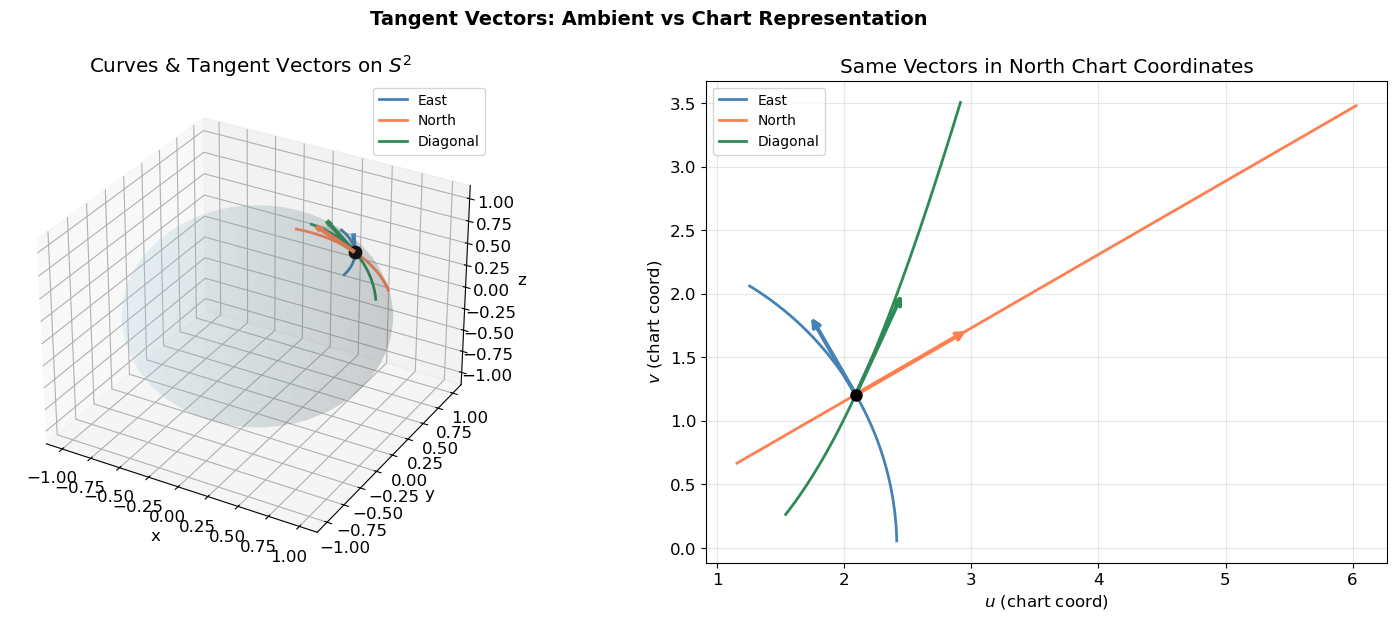

In [10]:
# ---- Visualize tangent vectors on S^2 ----
fig = plt.figure(figsize=(16, 6))

# Left: curves and tangent vectors on the sphere (ambient R^3)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X_s, Y_s, Z_s, alpha=0.12, color='lightblue', edgecolor='none')

colors_cv = [C_BLUE, C_RED, C_GREEN]
arrow_scale = 0.4

for idx, (name, gamma) in enumerate(curves):
    # Draw curve on sphere
    t_range = np.linspace(-0.5, 0.5, 100)
    pts = np.array([gamma(t) for t in t_range])
    ax1.plot(pts[:, 0], pts[:, 1], pts[:, 2], color=colors_cv[idx], linewidth=2, label=name)

    # Draw tangent vector in ambient coords
    v_amb = tangent_vector_ambient(gamma) * arrow_scale
    ax1.quiver(p0[0], p0[1], p0[2], v_amb[0], v_amb[1], v_amb[2],
               color=colors_cv[idx], arrow_length_ratio=0.15, linewidth=3)

ax1.scatter(*p0, color='k', s=80, zorder=10)
ax1.set_title('Curves & Tangent Vectors on $S^2$')
ax1.legend(fontsize=10)
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

# Right: the same tangent vectors in north chart coordinates
ax2 = fig.add_subplot(1, 2, 2)
coords_base = S2_north.phi(p0)

for idx, (name, gamma) in enumerate(curves):
    # Curve in chart coordinates
    t_range = np.linspace(-0.5, 0.5, 100)
    coords_curve = np.array([S2_north.phi(gamma(t)) for t in t_range])
    ax2.plot(coords_curve[:, 0], coords_curve[:, 1], color=colors_cv[idx], linewidth=2, label=name)

    # Tangent vector in chart
    v_N = tangent_vector_via_curve(gamma, S2_north) * 0.3
    ax2.annotate('', xy=coords_base + v_N, xytext=coords_base,
                 arrowprops=dict(arrowstyle='->', color=colors_cv[idx], lw=3))

ax2.plot(coords_base[0], coords_base[1], 'ko', markersize=8, zorder=10)
ax2.set_xlabel('$u$ (chart coord)')
ax2.set_ylabel('$v$ (chart coord)')
ax2.set_title('Same Vectors in North Chart Coordinates')
ax2.legend(fontsize=10)
ax2.set_aspect('equal')

plt.suptitle('Tangent Vectors: Ambient vs Chart Representation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Tangent Vectors via Derivations

There is an equivalent, purely algebraic definition of tangent vectors that avoids curves entirely.

### Definition

A **derivation** at $p \in M$ is a linear map $D: C^\infty(M) \to \mathbb{R}$ satisfying the **Leibniz rule**:

$$D(fg) = f(p) \cdot D(g) + g(p) \cdot D(f)$$

The set of all derivations at $p$ forms a vector space, which *is* the tangent space $T_pM$.

### Coordinate basis

In a chart $(U, \varphi)$ with coordinates $(x^1, \ldots, x^n)$, the **partial derivative operators** $\left\{\frac{\partial}{\partial x^i}\bigg|_p\right\}$ are derivations:

$$\frac{\partial}{\partial x^i}\bigg|_p (f) = \frac{\partial (f \circ \varphi^{-1})}{\partial x^i}\bigg|_{\varphi(p)}$$

These form a **basis** for $T_pM$, so every tangent vector can be written as $v = \sum_i v^i \frac{\partial}{\partial x^i}\bigg|_p$.

### Equivalence with the curve definition

Given a curve $\gamma$ with $\gamma(0) = p$, define $D_\gamma(f) = (f \circ \gamma)'(0)$. This is a derivation. Moreover, if $(\varphi \circ \gamma)'(0) = (v^1, \ldots, v^n)$, then:

$$D_\gamma = \sum_i v^i \frac{\partial}{\partial x^i}\bigg|_p$$

The two definitions produce the same vector space.

In [11]:
# =============================================================================
# Derivations
# =============================================================================

def derivation_via_curve(f, curve_func, t=0, dt=EPS):
    """Compute D_gamma(f) = (f . gamma)'(0) via finite difference.

    Args:
        f: Smooth function on the manifold (takes ambient coords). Callable.
        curve_func: gamma(t) -> ambient coords. Callable.
    """
    return (f(curve_func(t + dt)) - f(curve_func(t - dt))) / (2 * dt)


def derivation_via_coordinates(f_chart, v_chart, coords, eps=EPS):
    """Compute sum_i v^i (df/dx^i) at given chart coordinates.

    Args:
        f_chart: f . phi^{-1}: R^n -> R (function in chart coords). Callable.
        v_chart: Tangent vector components in chart. Shape: (n,).
        coords: Chart coordinates of the base point. Shape: (n,).
    """
    n = len(coords)
    result = 0.0
    for i in range(n):
        e = np.zeros(n)
        e[i] = eps
        df_dxi = (f_chart(coords + e) - f_chart(coords - e)) / (2 * eps)
        result += v_chart[i] * df_dxi
    return result


def verify_leibniz(D_func, f, g, p):
    """Verify Leibniz rule: D(fg) = f(p)*D(g) + g(p)*D(f).

    D_func: derivation callable (takes a function, returns scalar).
    """
    fg = lambda x: f(x) * g(x)
    lhs = D_func(fg)
    rhs = f(p) * D_func(g) + g(p) * D_func(f)
    return lhs, rhs, abs(lhs - rhs)

In [12]:
# ---- Test functions on S^2 (in ambient coords) ----
f1 = lambda p: p[2]                     # height function z
f2 = lambda p: p[0]**2 + p[1]**2        # distance from z-axis squared
f3 = lambda p: np.exp(p[2])             # smooth function of height

# Same functions in north chart coordinates: f . phi_N^{-1}
f1_chart = lambda uv: _S2_stereo_north_inv(uv)[2]
f2_chart = lambda uv: _S2_stereo_north_inv(uv)[0]**2 + _S2_stereo_north_inv(uv)[1]**2
f3_chart = lambda uv: np.exp(_S2_stereo_north_inv(uv)[2])

test_funcs = [("z (height)", f1, f1_chart),
              ("x^2+y^2", f2, f2_chart),
              ("exp(z)", f3, f3_chart)]

# Use the "east" curve from Section 3
v_N = tangent_vector_via_curve(curve_east, S2_north)
coords_N = S2_north.phi(p0)

print("=== Equivalence of Curve and Derivation Definitions ===\n")
all_pass = True
for fname, f_amb, f_ch in test_funcs:
    # Method 1: via curve
    D_curve = derivation_via_curve(f_amb, curve_east)

    # Method 2: via coordinate partial derivatives
    D_coord = derivation_via_coordinates(f_ch, v_N, coords_N)

    err = abs(D_curve - D_coord)
    ok = err < 1e-3
    all_pass &= ok
    print(f"  f = {fname}:")
    print(f"    D_curve(f)  = {D_curve:+.6f}")
    print(f"    D_coords(f) = {D_coord:+.6f}")
    print(f"    error = {err:.2e} [{'PASS' if ok else 'FAIL'}]")

# Verify Leibniz rule: D(fg) = f(p)D(g) + g(p)D(f)
print("\n--- Leibniz Rule Verification ---")
D_east = lambda f: derivation_via_curve(f, curve_east)
lhs, rhs, err = verify_leibniz(D_east, f1, f2, p0)
ok = err < 1e-3
all_pass &= ok
print(f"  D(z * (x^2+y^2)): LHS={lhs:+.6f}, RHS={rhs:+.6f}, err={err:.2e} [{'PASS' if ok else 'FAIL'}]")

lhs, rhs, err = verify_leibniz(D_east, f1, f3, p0)
ok = err < 1e-3
all_pass &= ok
print(f"  D(z * exp(z)):    LHS={lhs:+.6f}, RHS={rhs:+.6f}, err={err:.2e} [{'PASS' if ok else 'FAIL'}]")

print(f"\nAll derivation checks: [{'PASS' if all_pass else 'FAIL'}]")

=== Equivalence of Curve and Derivation Definitions ===

  f = z (height):
    D_curve(f)  = +0.000000
    D_coords(f) = -0.000000
    error = 5.64e-10 [PASS]
  f = x^2+y^2:
    D_curve(f)  = +0.000000
    D_coords(f) = -0.000000
    error = 1.85e-09 [PASS]
  f = exp(z):
    D_curve(f)  = +0.000000
    D_coords(f) = -0.000000
    error = 4.04e-09 [PASS]

--- Leibniz Rule Verification ---
  D(z * (x^2+y^2)): LHS=+0.000000, RHS=+0.000000, err=0.00e+00 [PASS]
  D(z * exp(z)):    LHS=+0.000000, RHS=+0.000000, err=0.00e+00 [PASS]

All derivation checks: [PASS]


---
## 5. The Pushforward (Differential) of Smooth Maps

Given a smooth map $F: M \to N$ between manifolds, the **pushforward** (or **differential**) at $p$ is the linear map:

$$dF_p: T_pM \to T_{F(p)}N$$

### Definition via curves

If $v = [\gamma] \in T_pM$, then $dF_p(v) = [F \circ \gamma] \in T_{F(p)}N$. That is, push the curve forward through $F$, then take the tangent vector of the resulting curve.

### In coordinates (= Jacobian)

Choose charts $(U, \varphi)$ on $M$ and $(V, \psi)$ on $N$. The coordinate representation of $F$ is $\hat{F} = \psi \circ F \circ \varphi^{-1}: \mathbb{R}^m \to \mathbb{R}^n$. Then:

$$[dF_p(v)]_\psi = J_{\hat{F}}(\varphi(p)) \cdot v_\varphi$$

where $J_{\hat{F}}$ is the **Jacobian matrix** of $\hat{F}$. **The pushforward is the abstract, coordinate-free version of the Jacobian.**

### Key properties

| Property | Statement |
|----------|-----------|
| **Linearity** | $dF_p(\alpha v + \beta w) = \alpha \, dF_p(v) + \beta \, dF_p(w)$ |
| **Chain rule** | $d(G \circ F)_p = dG_{F(p)} \circ dF_p$ |
| **Immersion** | $dF_p$ injective $\forall p$ ($F$ locally looks like an inclusion) |
| **Submersion** | $dF_p$ surjective $\forall p$ ($F$ locally looks like a projection) |
| **Embedding** | Injective immersion that is a homeomorphism onto its image |

### Robotics connection

For a robot arm with forward kinematics $FK: \text{Config Space} \to \text{Workspace}$, the pushforward $dFK$ is exactly the **manipulator Jacobian**: it maps joint velocities to end-effector velocities. **Singularities** occur where $dFK$ loses rank.

In [13]:
# =============================================================================
# Pushforward / Differential
# =============================================================================

def jacobian_numerical(F, x, eps=EPS):
    """Numerical Jacobian of F: R^m -> R^n at point x.

    Args:
        F: Callable, maps R^m to R^n.
        x: Point in R^m. Shape: (m,).

    Returns:
        J: Jacobian matrix. Shape: (n, m).
    """
    x = np.array(x, dtype=float)
    f0 = np.atleast_1d(F(x))
    m = len(x)
    n = len(f0)
    J = np.zeros((n, m))
    for i in range(m):
        e = np.zeros(m)
        e[i] = eps
        J[:, i] = (np.atleast_1d(F(x + e)) - np.atleast_1d(F(x - e))) / (2 * eps)
    return J


# =============================================================================
# Example 1: 2-link planar arm (FK as pushforward)
# =============================================================================

def forward_kinematics_2R(theta, l1=L1, l2=L2):
    """Forward kinematics for 2-link planar arm.

    Maps T^2 -> R^2: joint angles to end-effector position.
    """
    x = l1 * np.cos(theta[0]) + l2 * np.cos(theta[0] + theta[1])
    y = l1 * np.sin(theta[0]) + l2 * np.sin(theta[0] + theta[1])
    return np.array([x, y])


def fk_jacobian_2R(theta, l1=L1, l2=L2):
    """Analytical Jacobian of 2R forward kinematics."""
    s1 = np.sin(theta[0])
    c1 = np.cos(theta[0])
    s12 = np.sin(theta[0] + theta[1])
    c12 = np.cos(theta[0] + theta[1])
    return np.array([
        [-l1*s1 - l2*s12, -l2*s12],
        [ l1*c1 + l2*c12,  l2*c12],
    ])


# Verify numerical vs analytical Jacobian
print("=== Pushforward: 2R Robot Arm ===\n")
all_pass = True

test_configs = [
    ("General", np.array([np.pi/4, np.pi/3])),
    ("Singular (extended)", np.array([np.pi/4, 0.0])),
    ("Singular (folded)", np.array([np.pi/4, np.pi])),
]

for name, theta in test_configs:
    J_analytic = fk_jacobian_2R(theta)
    J_numeric = jacobian_numerical(forward_kinematics_2R, theta)
    err = np.linalg.norm(J_analytic - J_numeric)
    rank = np.linalg.matrix_rank(J_analytic, tol=1e-6)
    ok = err < 1e-4
    all_pass &= ok
    print(f"  {name}: theta=({np.degrees(theta[0]):.0f},{np.degrees(theta[1]):.0f}) deg")
    print(f"    Jacobian error: {err:.2e} [{'PASS' if ok else 'FAIL'}]")
    print(f"    Rank: {rank} {'(SINGULAR!)' if rank < 2 else '(full rank)'}\n")

# Verify chain rule: d(G.F) = dG . dF
# Let G: R^2 -> R be the norm squared, F = FK
G = lambda xy: np.array([xy[0]**2 + xy[1]**2])
GF = lambda theta: G(forward_kinematics_2R(theta))

theta_test = np.array([1.0, 0.8])
J_GF_direct = jacobian_numerical(GF, theta_test)
J_G = jacobian_numerical(G, forward_kinematics_2R(theta_test))
J_F = jacobian_numerical(forward_kinematics_2R, theta_test)
J_GF_chain = J_G @ J_F

err_chain = np.linalg.norm(J_GF_direct - J_GF_chain)
ok = err_chain < 1e-4
all_pass &= ok
print(f"Chain rule d(G.F) = dG . dF:")
print(f"  Direct:  {J_GF_direct.flatten()}")
print(f"  Chain:   {J_GF_chain.flatten()}")
print(f"  Error:   {err_chain:.2e} [{'PASS' if ok else 'FAIL'}]")
print(f"\nAll pushforward checks: [{'PASS' if all_pass else 'FAIL'}]")

=== Pushforward: 2R Robot Arm ===

  General: theta=(45,60) deg
    Jacobian error: 1.89e-09 [PASS]
    Rank: 2 (full rank)

  Singular (extended): theta=(45,0) deg
    Jacobian error: 1.82e-09 [PASS]
    Rank: 1 (SINGULAR!)

  Singular (folded): theta=(45,180) deg
    Jacobian error: 1.40e-09 [PASS]
    Rank: 1 (SINGULAR!)

Chain rule d(G.F) = dG . dF:
  Direct:  [ 2.22044605e-09 -1.14776975e+00]
  Chain:   [ 3.99640195e-09 -1.14776975e+00]
  Error:   1.99e-09 [PASS]

All pushforward checks: [PASS]


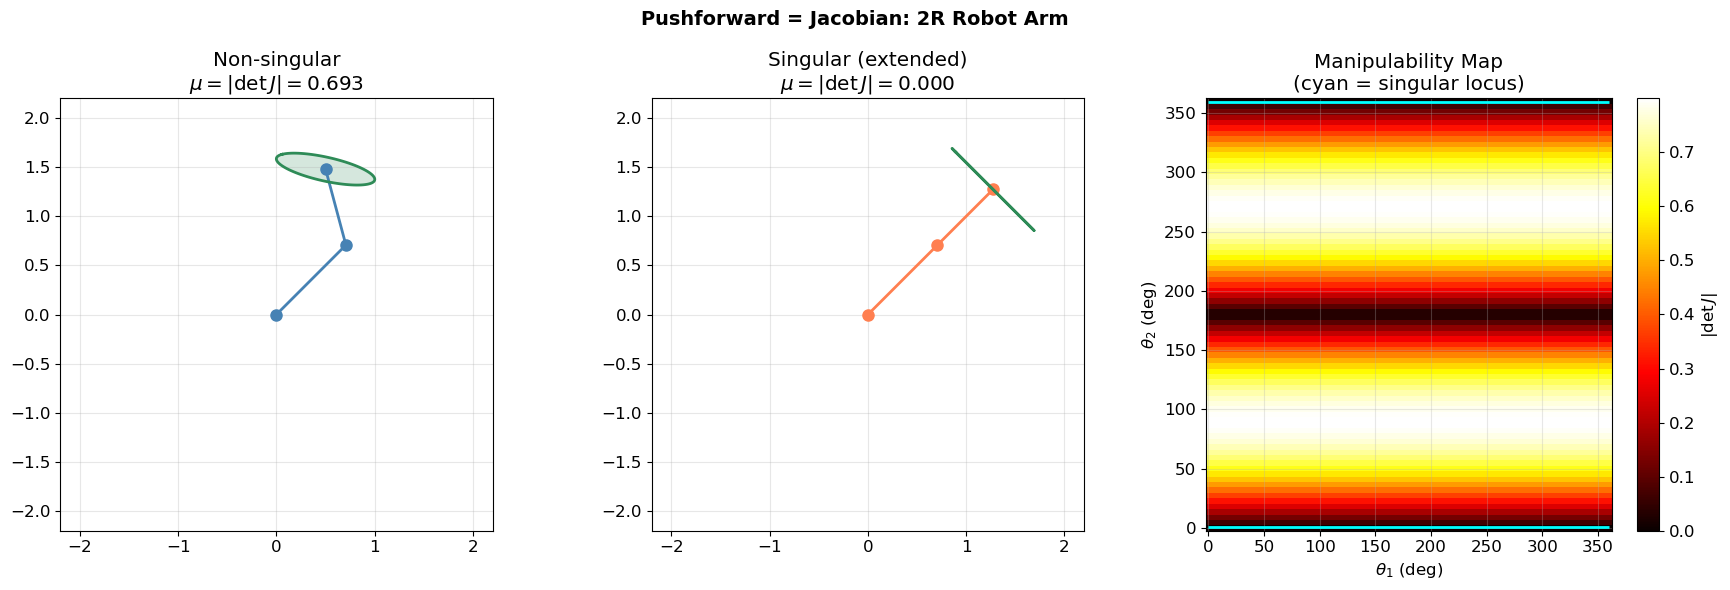

In [14]:
# ---- Visualize: 2R arm, manipulability ellipses, singularities ----

def draw_2R_arm(ax, theta, l1=L1, l2=L2, color='k', linewidth=2):
    """Draw a 2-link planar arm on a matplotlib axes."""
    j0 = np.array([0, 0])
    j1 = np.array([l1 * np.cos(theta[0]), l1 * np.sin(theta[0])])
    j2 = forward_kinematics_2R(theta, l1, l2)
    ax.plot([j0[0], j1[0], j2[0]], [j0[1], j1[1], j2[1]],
            'o-', color=color, linewidth=linewidth, markersize=8)
    return j2

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left: non-singular configuration with manipulability ellipse
ax = axes[0]
theta_ns = np.array([np.pi/4, np.pi/3])
ee = draw_2R_arm(ax, theta_ns, color=C_BLUE)
J = fk_jacobian_2R(theta_ns)
# Manipulability ellipse: image of unit circle under J
angles_e = np.linspace(0, 2*np.pi, 100)
unit_circle = np.array([np.cos(angles_e), np.sin(angles_e)])
ellipse = J @ unit_circle * 0.3  # scale for visibility
ax.plot(ee[0] + ellipse[0], ee[1] + ellipse[1], color=C_GREEN, linewidth=2)
ax.fill(ee[0] + ellipse[0], ee[1] + ellipse[1], color=C_GREEN, alpha=0.2)
manipulability = abs(np.linalg.det(J))
ax.set_title(f'Non-singular\n$\\mu = |\\det J| = {manipulability:.3f}$')
ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2); ax.set_aspect('equal')

# Middle: singular (extended)
ax = axes[1]
theta_ext = np.array([np.pi/4, 0.0])
ee = draw_2R_arm(ax, theta_ext, color=C_RED)
J = fk_jacobian_2R(theta_ext)
ellipse = J @ unit_circle * 0.3
ax.plot(ee[0] + ellipse[0], ee[1] + ellipse[1], color=C_GREEN, linewidth=2)
manipulability = abs(np.linalg.det(J))
ax.set_title(f'Singular (extended)\n$\\mu = |\\det J| = {manipulability:.3f}$')
ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2); ax.set_aspect('equal')

# Right: manipulability map over config space
ax = axes[2]
n_grid = 80
th1 = np.linspace(0, 2*np.pi, n_grid)
th2 = np.linspace(0, 2*np.pi, n_grid)
TH1, TH2 = np.meshgrid(th1, th2)
MU = np.zeros_like(TH1)
for i in range(n_grid):
    for j in range(n_grid):
        J = fk_jacobian_2R(np.array([TH1[i,j], TH2[i,j]]))
        MU[i,j] = abs(np.linalg.det(J))

im = ax.pcolormesh(np.degrees(TH1), np.degrees(TH2), MU, cmap='hot', shading='auto')
ax.contour(np.degrees(TH1), np.degrees(TH2), MU, levels=[0.01], colors=['cyan'], linewidths=2)
plt.colorbar(im, ax=ax, label='$|\\det J|$')
ax.set_xlabel('$\\theta_1$ (deg)'); ax.set_ylabel('$\\theta_2$ (deg)')
ax.set_title('Manipulability Map\n(cyan = singular locus)')

plt.suptitle('Pushforward = Jacobian: 2R Robot Arm', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Example 2: The Inclusion $\iota: S^2 \hookrightarrow \mathbb{R}^3$

The inclusion map $\iota(p) = p$ has pushforward $d\iota_p: T_pS^2 \to T_{\iota(p)}\mathbb{R}^3 \cong \mathbb{R}^3$.

This is an **immersion** (rank 2 everywhere): it embeds the 2D tangent plane into 3D ambient space. This is how we visualize tangent vectors as arrows in $\mathbb{R}^3$.

### Example 3: Normalization $\pi: \mathbb{R}^3 \setminus \{0\} \to S^2$

The map $\pi(x) = x / \|x\|$ is a **submersion** (rank 2 for all $x \neq 0$): its pushforward projects 3D velocity vectors onto the 2D tangent plane of the sphere.

In [15]:
# =============================================================================
# Examples 2 & 3: Inclusion and Normalization
# =============================================================================

# Inclusion: iota(p) = p (identity on ambient coords)
# In charts: psi . iota . phi^{-1} where psi is the identity chart on R^3
# d(iota)_p maps T_pS^2 (2D) -> R^3
# We compute this as the Jacobian of phi_N^{-1}: R^2 -> R^3

print("=== Immersion: S^2 -> R^3 ===\n")
p_test = np.array([1/np.sqrt(3), 1/np.sqrt(3), 1/np.sqrt(3)])
p_test = p_test / np.linalg.norm(p_test)
coords_N = S2_north.phi(p_test)

# Jacobian of phi_N^{-1}: R^2 -> R^3 (this IS the pushforward d(iota) in these coords)
J_incl = jacobian_numerical(_S2_stereo_north_inv, coords_N)
rank_incl = np.linalg.matrix_rank(J_incl, tol=1e-6)
print(f"Inclusion Jacobian at p = {p_test.round(3)}:")
print(f"  J shape: {J_incl.shape} (3x2)")
print(f"  Rank: {rank_incl} [{'PASS' if rank_incl == 2 else 'FAIL'}] (immersion requires rank 2)")

# Verify columns of J are tangent to the sphere (orthogonal to p)
for i in range(2):
    dot = abs(np.dot(J_incl[:, i], p_test))
    print(f"  |J[:,{i}] . p| = {dot:.2e} (should be ~0)")

# Normalization: pi(x) = x/||x||
normalize = lambda x: x / np.linalg.norm(x)

print("\n=== Submersion: R^3 -> S^2 ===\n")
x_test = np.array([2.0, 1.0, 3.0])
J_norm = jacobian_numerical(normalize, x_test)

# The rank should be 2 (maps R^3 to the 2D sphere -- loses 1 dimension along radial direction)
rank_norm = np.linalg.matrix_rank(J_norm, tol=1e-6)
print(f"Normalization Jacobian at x = {x_test}:")
print(f"  J shape: {J_norm.shape} (3x3)")
print(f"  Rank: {rank_norm} [{'PASS' if rank_norm == 2 else 'FAIL'}] (submersion requires rank = dim(target) = 2)")

# The null space of d(pi) should be the radial direction
_, S, Vt = np.linalg.svd(J_norm)
null_vec = Vt[-1]  # last row of V^T = smallest singular vector
radial = x_test / np.linalg.norm(x_test)
alignment = abs(np.dot(null_vec, radial))
print(f"  Null space alignment with radial direction: {alignment:.6f} [{'PASS' if alignment > 0.99 else 'FAIL'}]")

=== Immersion: S^2 -> R^3 ===

Inclusion Jacobian at p = [0.577 0.577 0.577]:
  J shape: (3, 2) (3x2)
  Rank: 2 [PASS] (immersion requires rank 2)
  |J[:,0] . p| = 6.41e-10 (should be ~0)
  |J[:,1] . p| = 6.41e-10 (should be ~0)

=== Submersion: R^3 -> S^2 ===

Normalization Jacobian at x = [2. 1. 3.]:
  J shape: (3, 3) (3x3)
  Rank: 2 [PASS] (submersion requires rank = dim(target) = 2)
  Null space alignment with radial direction: 1.000000 [PASS]


---
## 6. The Tangent Bundle

### Definition

The **tangent bundle** of $M$ is:

$$TM = \bigsqcup_{p \in M} T_pM = \{(p, v) : p \in M, \, v \in T_pM\}$$

$TM$ is itself a smooth manifold of dimension $2n$ (if $\dim M = n$).

### Charts on $TM$

Given a chart $(U, \varphi)$ on $M$, define a chart $(TU, \Phi)$ on $TM$:

$$\Phi(p, v) = (\varphi(p), \, d\varphi_p(v)) \in \mathbb{R}^{2n}$$

This maps (point, tangent vector) to (coordinates, coordinate components).

### Physical interpretation

For a mechanical system with configuration manifold $M$, the **tangent bundle** $TM$ is the **phase space** (positions + velocities):
- $M = S^1$ (pendulum angle): $TS^1 \cong S^1 \times \mathbb{R}$ (a cylinder) — angle + angular velocity
- $M = T^2$ (2-link arm): $TT^2$ has dimension 4 — two angles + two angular velocities
- $M = S^2$: $TS^2$ has dimension 4, but is **not** diffeomorphic to $S^2 \times \mathbb{R}^2$ (by the **hairy ball theorem**: you cannot comb a sphere without creating a cowlick)

### The simple pendulum on $TS^1$

The pendulum has configuration space $S^1$ (the angle $\theta$). Its state space is $TS^1$, which we can visualize as a cylinder $(\\theta, \dot\\theta)$. The pendulum ODE is:

$$\ddot{\theta} = -\frac{g}{l}\sin\theta$$

Trajectories on the cylinder are the familiar phase portrait: closed orbits (oscillation), separatrices, and unbounded orbits (rotation).

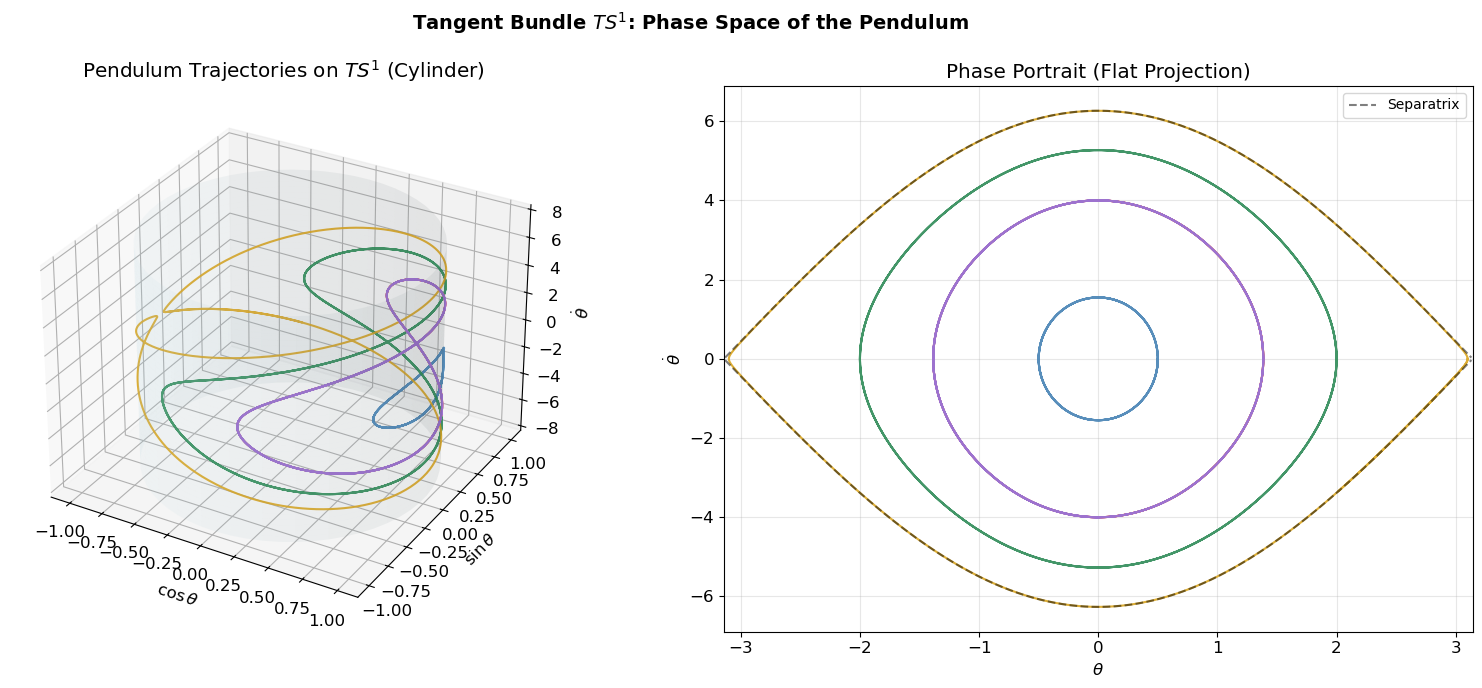

Energy conservation: initial E=4.082400, final E=4.082400, drift=3.26e-09 [PASS]


In [16]:
# =============================================================================
# Tangent Bundle: TS^1 as a cylinder, pendulum phase portrait
# =============================================================================

def simulate_pendulum(theta0, omega0, t_max=10.0, g=9.81, l=1.0, n_pts=2000):
    """Simulate simple pendulum: theta'' = -(g/l) sin(theta).

    Returns trajectory on TS^1 = (theta, omega).
    """
    def ode(t, state):
        theta, omega = state
        return [omega, -(g/l) * np.sin(theta)]

    sol = solve_ivp(ode, [0, t_max], [theta0, omega0],
                    t_eval=np.linspace(0, t_max, n_pts), rtol=1e-10, atol=1e-12)
    return sol.t, sol.y[0], sol.y[1]  # t, theta, omega


# Simulate multiple initial conditions
fig = plt.figure(figsize=(16, 7))

# Left: phase portrait on the cylinder (TS^1)
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# Draw the cylinder
theta_cyl = np.linspace(-np.pi, np.pi, 60)
omega_cyl = np.linspace(-8, 8, 40)
TH_c, OM_c = np.meshgrid(theta_cyl, omega_cyl)
X_cyl = np.cos(TH_c)
Y_cyl = np.sin(TH_c)
Z_cyl = OM_c
ax1.plot_surface(X_cyl, Y_cyl, Z_cyl, alpha=0.08, color='lightblue', edgecolor='none')

# Trajectories with different initial conditions
ics = [
    (0.5, 0, C_BLUE),    # small oscillation
    (2.0, 0, C_GREEN),    # large oscillation
    (3.1, 0, C_GOLD),     # near separatrix
    (0, 4.0, C_RED),      # rotation (high energy)
    (0, -4.0, C_PURPLE),  # rotation (opposite direction)
]

for theta0, omega0, color in ics:
    t, theta, omega = simulate_pendulum(theta0, omega0, t_max=8.0)
    # Wrap theta to [-pi, pi] for cylinder visualization
    theta_wrapped = np.arctan2(np.sin(theta), np.cos(theta))
    ax1.plot(np.cos(theta_wrapped), np.sin(theta_wrapped), omega,
             color=color, linewidth=1.5, alpha=0.9)

ax1.set_xlabel('$\\cos\\theta$')
ax1.set_ylabel('$\\sin\\theta$')
ax1.set_zlabel('$\\dot{\\theta}$')
ax1.set_title('Pendulum Trajectories on $TS^1$ (Cylinder)')

# Right: standard 2D phase portrait
ax2 = fig.add_subplot(1, 2, 2)

for theta0, omega0, color in ics:
    t, theta, omega = simulate_pendulum(theta0, omega0, t_max=8.0)
    theta_wrapped = np.arctan2(np.sin(theta), np.cos(theta))
    ax2.plot(theta_wrapped, omega, color=color, linewidth=1.5, alpha=0.9)

# Add separatrix (energy = mgl)
theta_sep = np.linspace(-np.pi + 0.01, np.pi - 0.01, 200)
omega_sep = np.sqrt(2 * 9.81 * (1 + np.cos(theta_sep)))  # E = mgl
ax2.plot(theta_sep, omega_sep, 'k--', linewidth=1.5, alpha=0.5, label='Separatrix')
ax2.plot(theta_sep, -omega_sep, 'k--', linewidth=1.5, alpha=0.5)
ax2.set_xlabel('$\\theta$')
ax2.set_ylabel('$\\dot{\\theta}$')
ax2.set_title('Phase Portrait (Flat Projection)')
ax2.legend(fontsize=10)
ax2.set_xlim(-np.pi, np.pi)

plt.suptitle('Tangent Bundle $TS^1$: Phase Space of the Pendulum', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Verify energy conservation
t, theta, omega = simulate_pendulum(2.0, 0, t_max=20.0)
g, l = 9.81, 1.0
energy = 0.5 * l**2 * omega**2 - g * l * np.cos(theta)
e_drift = abs(energy[-1] - energy[0]) / abs(energy[0])
status = "PASS" if e_drift < 1e-6 else "FAIL"
print(f"Energy conservation: initial E={energy[0]:.6f}, final E={energy[-1]:.6f}, "
      f"drift={e_drift:.2e} [{status}]")

---
## 7. Vector Fields and Flows

### Definition

A **vector field** $X$ on $M$ assigns to each point $p$ a tangent vector $X(p) \in T_pM$. Formally, it is a smooth **section** of the tangent bundle: $X: M \to TM$ with $\pi \circ X = \text{id}_M$.

In coordinates: $X = \sum_i X^i(x) \frac{\partial}{\partial x^i}$ where $X^i: U \to \mathbb{R}$ are smooth functions.

### Flows

The **flow** of $X$ is the family of maps $\Phi_t: M \to M$ satisfying:

$$\frac{d}{dt}\Phi_t(p) = X(\Phi_t(p)), \qquad \Phi_0(p) = p$$

By existence and uniqueness of ODEs, the flow exists locally. It satisfies the **one-parameter group property**: $\Phi_{s+t} = \Phi_s \circ \Phi_t$.

**Connection to Lie groups:** For a Lie group $G$, left-invariant vector fields generate flows that are the one-parameter subgroups $t \mapsto \exp(tA)$. See the [Lie Groups notebook](../../linear-algebra/lie-groups/lie_groups.ipynb).

### Three examples

1. **Rotation field on $S^2$**: $X(p) = e_z \times p$ generates rotation about the $z$-axis. Integral curves are latitude lines.
2. **Gradient of height on $S^2$**: $\text{grad}(z)$ points uphill toward the north pole. Two fixed points: north (stable) and south (unstable). The **hairy ball theorem** says every continuous vector field on $S^2$ has a zero — we see both here.
3. **Irrational flow on $T^2$**: $X = (1, \sqrt{2})$ in angle coordinates. Since $\sqrt{2}$ is irrational, every orbit is **dense** on the torus — it comes arbitrarily close to every point.

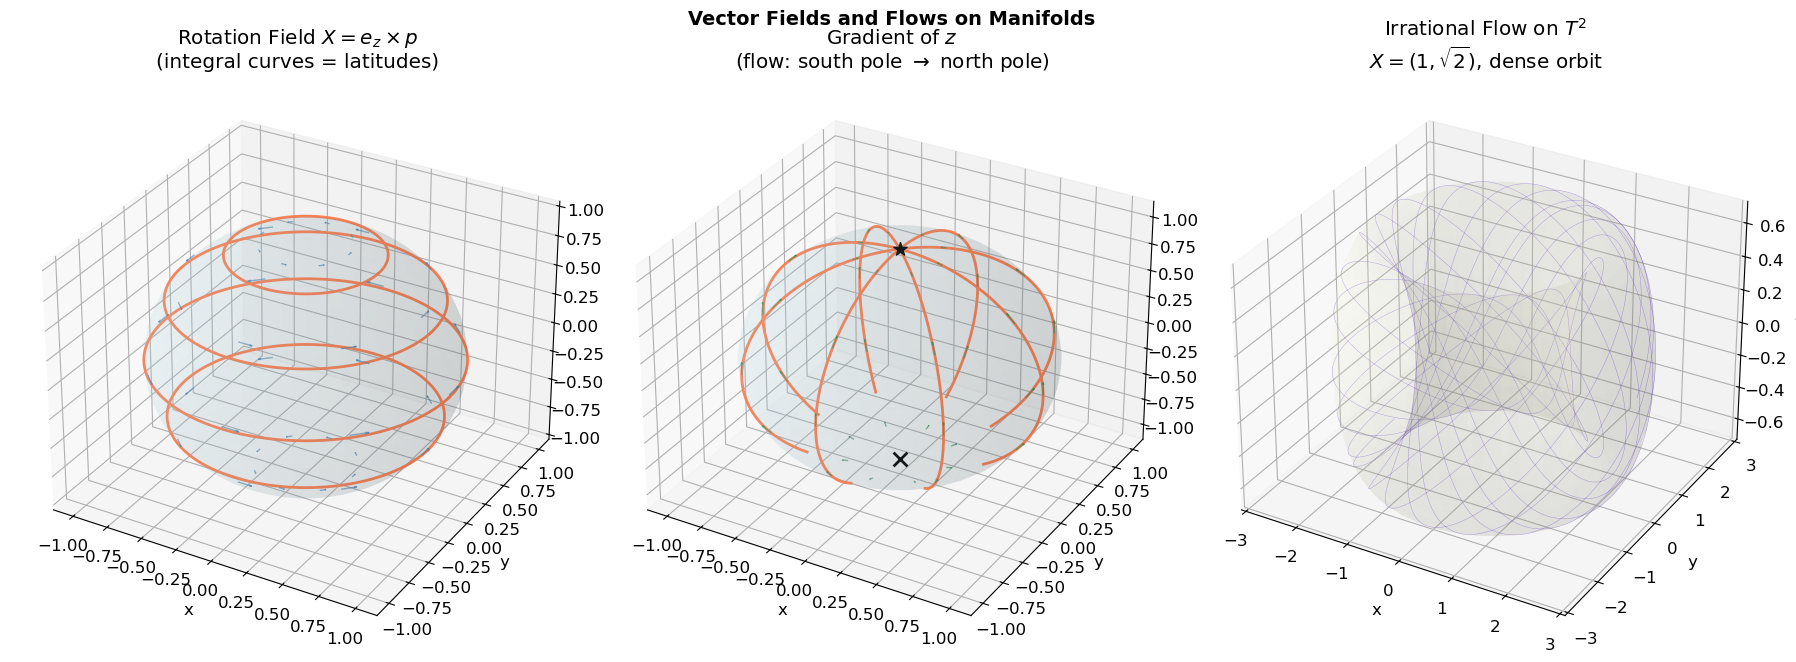

In [17]:
# =============================================================================
# Vector Fields and Flows
# =============================================================================

def flow_on_sphere(vector_field, p0, t_max=5.0, n_pts=1000):
    """Integrate the flow of a vector field on S^2 (in ambient R^3 coords).

    Projects back onto the sphere at each step to stay on the manifold.
    """
    def ode(t, p):
        p_normalized = p / np.linalg.norm(p)
        return vector_field(p_normalized)

    sol = solve_ivp(ode, [0, t_max], p0, t_eval=np.linspace(0, t_max, n_pts),
                    rtol=1e-10, atol=1e-12)
    # Project onto sphere
    traj = sol.y.T
    norms = np.linalg.norm(traj, axis=1, keepdims=True)
    traj = traj / norms
    return sol.t, traj


# --- Vector field 1: Rotation about z-axis ---
def rotation_field_S2(p):
    """X(p) = e_z x p. Tangent to S^2 by construction."""
    ez = np.array([0, 0, 1.0])
    return np.cross(ez, p)


# --- Vector field 2: Gradient of height function z ---
def gradient_height_S2(p):
    """grad(z) on S^2 with round metric = projection of (0,0,1) onto T_pS^2."""
    ez = np.array([0, 0, 1.0])
    # Project ez onto tangent plane: ez - (ez . p)p
    return ez - np.dot(ez, p) * p


# ---- Visualize both fields on S^2 ----
fig = plt.figure(figsize=(18, 7))

# Draw sphere wireframe helper
u_w = np.linspace(0, np.pi, 30)
v_w = np.linspace(0, 2 * np.pi, 40)
Uw, Vw = np.meshgrid(u_w, v_w)
X_sp = np.sin(Uw) * np.cos(Vw)
Y_sp = np.sin(Uw) * np.sin(Vw)
Z_sp = np.cos(Uw)

# Left: rotation field with integral curves
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
ax1.plot_surface(X_sp, Y_sp, Z_sp, alpha=0.1, color='lightblue', edgecolor='none')

# Arrow field
n_arrows = 8
for u0 in np.linspace(0.3, 2.8, 5):
    for v0 in np.linspace(0, 2*np.pi, n_arrows, endpoint=False):
        p = np.array([np.sin(u0)*np.cos(v0), np.sin(u0)*np.sin(v0), np.cos(u0)])
        v = rotation_field_S2(p) * 0.12
        ax1.quiver(p[0], p[1], p[2], v[0], v[1], v[2],
                   color=C_BLUE, alpha=0.6, arrow_length_ratio=0.2, linewidth=1)

# Integral curves (latitude lines)
for lat_angle in [np.pi/6, np.pi/3, np.pi/2, 2*np.pi/3]:
    p_start = np.array([np.sin(lat_angle), 0, np.cos(lat_angle)])
    t, traj = flow_on_sphere(rotation_field_S2, p_start, t_max=6.28)
    ax1.plot(traj[:, 0], traj[:, 1], traj[:, 2], color=C_RED, linewidth=2)

ax1.set_title('Rotation Field $X = e_z \\times p$\n(integral curves = latitudes)')
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

# Middle: gradient field with flow lines
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
ax2.plot_surface(X_sp, Y_sp, Z_sp, alpha=0.1, color='lightblue', edgecolor='none')

for u0 in np.linspace(0.3, 2.8, 5):
    for v0 in np.linspace(0, 2*np.pi, n_arrows, endpoint=False):
        p = np.array([np.sin(u0)*np.cos(v0), np.sin(u0)*np.sin(v0), np.cos(u0)])
        v = gradient_height_S2(p) * 0.12
        ax2.quiver(p[0], p[1], p[2], v[0], v[1], v[2],
                   color=C_GREEN, alpha=0.6, arrow_length_ratio=0.2, linewidth=1)

# Flow lines from southern hemisphere toward north pole
for v0 in np.linspace(0, 2*np.pi, 8, endpoint=False):
    p_start = np.array([np.sin(2.5)*np.cos(v0), np.sin(2.5)*np.sin(v0), np.cos(2.5)])
    t, traj = flow_on_sphere(gradient_height_S2, p_start, t_max=8.0)
    ax2.plot(traj[:, 0], traj[:, 1], traj[:, 2], color=C_RED, linewidth=2)

# Mark fixed points
ax2.scatter(0, 0, 1, color='k', s=100, marker='*', zorder=10)   # stable
ax2.scatter(0, 0, -1, color='k', s=100, marker='x', zorder=10)  # unstable
ax2.set_title('Gradient of $z$\n(flow: south pole $\\to$ north pole)')
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('z')

# Right: irrational flow on T^2
ax3 = fig.add_subplot(1, 3, 3, projection='3d')

# Draw torus
R_tor, r_tor = 2.0, 0.7
u_t = np.linspace(0, 2*np.pi, 60)
v_t = np.linspace(0, 2*np.pi, 60)
Ut, Vt = np.meshgrid(u_t, v_t)
X_tor = (R_tor + r_tor * np.cos(Vt)) * np.cos(Ut)
Y_tor = (R_tor + r_tor * np.cos(Vt)) * np.sin(Ut)
Z_tor = r_tor * np.sin(Vt)
ax3.plot_surface(X_tor, Y_tor, Z_tor, alpha=0.1, color='lightyellow', edgecolor='none')

# Irrational flow: theta1' = 1, theta2' = sqrt(2)
omega_ratio = np.sqrt(2)
t_flow = np.linspace(0, 80, 10000)
th1 = t_flow % (2*np.pi)
th2 = (omega_ratio * t_flow) % (2*np.pi)
X_flow = (R_tor + r_tor * np.cos(th2)) * np.cos(th1)
Y_flow = (R_tor + r_tor * np.cos(th2)) * np.sin(th1)
Z_flow = r_tor * np.sin(th2)
ax3.plot(X_flow, Y_flow, Z_flow, color=C_PURPLE, linewidth=0.3, alpha=0.8)

ax3.set_title('Irrational Flow on $T^2$\n$X = (1, \\sqrt{2})$, dense orbit')
ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel('z')

plt.suptitle('Vector Fields and Flows on Manifolds', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# ---- Verification of flow properties ----
print("=== Flow Verification ===\n")
all_pass = True

# 1. Rotation flow stays on S^2
p_start = np.array([np.sin(np.pi/4), 0, np.cos(np.pi/4)])
t, traj = flow_on_sphere(rotation_field_S2, p_start, t_max=10.0)
norm_err = np.max(np.abs(np.linalg.norm(traj, axis=1) - 1.0))
ok = norm_err < 1e-6
all_pass &= ok
print(f"Rotation flow stays on S^2: max ||p|| - 1 = {norm_err:.2e} [{'PASS' if ok else 'FAIL'}]")

# 2. One-parameter group property: Phi_{s+t}(p) = Phi_s(Phi_t(p))
s, t_val = 1.5, 2.3
_, traj_st = flow_on_sphere(rotation_field_S2, p_start, t_max=s+t_val, n_pts=2000)
p_st = traj_st[-1]  # Phi_{s+t}(p)

_, traj_t = flow_on_sphere(rotation_field_S2, p_start, t_max=t_val, n_pts=1000)
p_t = traj_t[-1]  # Phi_t(p)
_, traj_s = flow_on_sphere(rotation_field_S2, p_t, t_max=s, n_pts=1000)
p_s_t = traj_s[-1]  # Phi_s(Phi_t(p))

err_group = np.linalg.norm(p_st - p_s_t)
ok = err_group < 1e-4
all_pass &= ok
print(f"One-parameter group: ||Phi_{{s+t}}(p) - Phi_s(Phi_t(p))|| = {err_group:.2e} [{'PASS' if ok else 'FAIL'}]")

# 3. Gradient flow increases height
p_start_south = np.array([np.sin(2.0), 0, np.cos(2.0)])
t, traj_grad = flow_on_sphere(gradient_height_S2, p_start_south, t_max=5.0)
heights = traj_grad[:, 2]
monotone = np.all(np.diff(heights) >= -1e-8)
ok = monotone
all_pass &= ok
print(f"Gradient flow increases z: monotone = {monotone} [{'PASS' if ok else 'FAIL'}]")

# 4. Irrational flow density: check orbit approaches all points on T^2
t_long = np.linspace(0, 500, 100000)
th1_long = t_long % (2*np.pi)
th2_long = (np.sqrt(2) * t_long) % (2*np.pi)
# Check min distance to grid of target points
n_check = 10
targets_1 = np.linspace(0, 2*np.pi, n_check, endpoint=False)
targets_2 = np.linspace(0, 2*np.pi, n_check, endpoint=False)
max_min_dist = 0
for t1 in targets_1:
    for t2 in targets_2:
        # Distance on T^2 (torus metric)
        d1 = np.minimum(np.abs(th1_long - t1), 2*np.pi - np.abs(th1_long - t1))
        d2 = np.minimum(np.abs(th2_long - t2), 2*np.pi - np.abs(th2_long - t2))
        min_dist = np.min(np.sqrt(d1**2 + d2**2))
        max_min_dist = max(max_min_dist, min_dist)

ok = max_min_dist < 0.15
all_pass &= ok
print(f"Irrational flow density: max(min dist to grid) = {max_min_dist:.4f} [{'PASS' if ok else 'FAIL'}]")

print(f"\nAll flow checks: [{'PASS' if all_pass else 'FAIL'}]")

=== Flow Verification ===

Rotation flow stays on S^2: max ||p|| - 1 = 2.22e-16 [PASS]
One-parameter group: ||Phi_{s+t}(p) - Phi_s(Phi_t(p))|| = 1.61e-10 [PASS]
Gradient flow increases z: monotone = True [PASS]
Irrational flow density: max(min dist to grid) = 0.0312 [PASS]

All flow checks: [PASS]


---
## 8. Pullback of Functions and 1-Forms

The **pullback** is the dual operation to the pushforward. While the pushforward moves tangent vectors *forward* along a map $F: M \to N$, the pullback moves covectors (and functions) *backward*.

### Pullback of functions

Given $F: M \to N$ and $g: N \to \mathbb{R}$, the **pullback** is:

$$F^*g = g \circ F: M \to \mathbb{R}$$

Simply compose: evaluate $g$ at the image point.

### Pullback of 1-forms

A **1-form** (covector field) $\omega$ on $N$ assigns to each point $q \in N$ a linear map $\omega_q: T_qN \to \mathbb{R}$. The pullback is:

$$(F^*\omega)_p(v) = \omega_{F(p)}(dF_p(v))$$

In coordinates: if $\omega = \sum_j \omega_j \, dy^j$ and $F$ maps $x \mapsto y(x)$, then:

$$F^*\omega = \sum_{i,j} \omega_j \frac{\partial y^j}{\partial x^i} dx^i$$

The pullback uses the **transpose of the Jacobian**: $(F^*\omega)_i = \sum_j J^j{}_i \, \omega_j$, i.e., $F^*\omega = J^T \omega$.

### Duality summary

| | Pushforward $dF$ | Pullback $F^*$ |
|---|---|---|
| **Direction** | Forward: $M \to N$ | Backward: $N \to M$ |
| **Acts on** | Tangent vectors (contravariant) | Covectors/forms (covariant) |
| **Matrix** | Jacobian $J$ | Transpose $J^T$ |

### Robotics interpretation

If $\omega$ represents a **force** at the end-effector, then $F^*\omega = J^T \omega$ gives the corresponding **joint torques**. This is precisely the force-torque duality in robotics: the transpose Jacobian maps workspace forces to joint-space torques.

In [19]:
# =============================================================================
# Pullback
# =============================================================================

def pullback_function(F, g):
    """Pullback of a function: F*g = g . F."""
    return lambda x: g(F(x))


def pullback_oneform(F, omega_components, x, eps=EPS):
    """Pullback of a 1-form: (F*omega)_i = sum_j J^j_i * omega_j = (J^T omega)_i.

    Args:
        F: Map from R^m -> R^n. Callable.
        omega_components: 1-form components at F(x). Shape: (n,).
        x: Point in R^m. Shape: (m,).

    Returns:
        pullback_components: (F*omega) components at x. Shape: (m,).
    """
    J = jacobian_numerical(F, x, eps=eps)
    return J.T @ omega_components


# ---- Verify pullback of functions ----
print("=== Pullback Verification ===\n")
all_pass = True

# g: R^2 -> R, g(x,y) = x^2 + y^2 (distance squared)
g_dist = lambda xy: xy[0]**2 + xy[1]**2
Fstar_g = pullback_function(forward_kinematics_2R, g_dist)

theta_test = np.array([np.pi/4, np.pi/3])
val_pullback = Fstar_g(theta_test)
val_direct = g_dist(forward_kinematics_2R(theta_test))
err = abs(val_pullback - val_direct)
ok = err < TOL
all_pass &= ok
print(f"F*g(theta) = g(FK(theta)): {val_pullback:.6f} vs {val_direct:.6f}, err={err:.2e} [{'PASS' if ok else 'FAIL'}]")

# ---- Verify pullback of 1-form (force-torque duality) ----
# A horizontal force [Fx, Fy] at the end-effector
ee_force = np.array([1.0, 0.5])  # Newton

# Pullback: joint torques = J^T . force
joint_torques = pullback_oneform(forward_kinematics_2R, ee_force, theta_test)
J = fk_jacobian_2R(theta_test)
torques_direct = J.T @ ee_force

err = np.linalg.norm(joint_torques - torques_direct)
ok = err < TOL
all_pass &= ok
print(f"\nForce-torque duality:")
print(f"  EE force:      {ee_force}")
print(f"  Joint torques (pullback): {joint_torques}")
print(f"  Joint torques (J^T F):    {torques_direct}")
print(f"  Error: {err:.2e} [{'PASS' if ok else 'FAIL'}]")

# ---- Naturality: d(F*g) = F*(dg) ----
# d(F*g) = gradient of (g . FK) at theta
# F*(dg) = J^T . (grad g at FK(theta))
grad_Fstarg = jacobian_numerical(Fstar_g, theta_test).flatten()  # d(F*g)

# grad g at FK(theta): for g(x,y) = x^2+y^2, grad g = (2x, 2y)
ee_pos = forward_kinematics_2R(theta_test)
grad_g = np.array([2*ee_pos[0], 2*ee_pos[1]])
Fstar_dg = pullback_oneform(forward_kinematics_2R, grad_g, theta_test)  # F*(dg)

err_nat = np.linalg.norm(grad_Fstarg - Fstar_dg)
ok = err_nat < 1e-4
all_pass &= ok
print(f"\nNaturality d(F*g) = F*(dg):")
print(f"  d(F*g):  {grad_Fstarg}")
print(f"  F*(dg):  {Fstar_dg}")
print(f"  Error:   {err_nat:.2e} [{'PASS' if ok else 'FAIL'}]")

print(f"\nAll pullback checks: [{'PASS' if all_pass else 'FAIL'}]")

=== Pullback Verification ===

F*g(theta) = g(FK(theta)): 2.440000 vs 2.440000, err=0.00e+00 [PASS]

Force-torque duality:
  EE force:      [1.  0.5]
  Joint torques (pullback): [-1.22982167 -0.87626828]
  Joint torques (J^T F):    [-1.22982167 -0.87626828]
  Error: 9.47e-10 [PASS]

Naturality d(F*g) = F*(dg):
  d(F*g):  [-6.66133815e-09 -1.38564064e+00]
  F*(dg):  [-4.87811218e-09 -1.38564064e+00]
  Error:   1.89e-09 [PASS]

All pullback checks: [PASS]


---
## 9. Capstone Application: Configuration Space of a 3-Link Arm

We now tie together all the concepts on a substantial example: the **3-link planar robot arm**.

**Setup:**
- Three links with lengths $l_1, l_2, l_3$ and joint angles $\theta_1, \theta_2, \theta_3$
- **Configuration manifold**: $T^3 = S^1 \times S^1 \times S^1$ (3-torus), dimension 3
- **Forward kinematics**: $FK: T^3 \to \mathbb{R}^2$ (end-effector position)
- Since $\dim(T^3) = 3 > 2 = \dim(\mathbb{R}^2)$, the FK map is a **submersion** at generic points
- **Self-motion manifolds**: preimages $FK^{-1}(x_0)$ are generically 1-dimensional submanifolds of $T^3$

This example demonstrates:
- **Charts** (angle wrapping on $T^3$)
- **Pushforward** (Jacobian = manipulator Jacobian)
- **Tangent bundle** (phase space $TT^3$ for resolved-rate control)
- **Vector fields** (nullspace field on self-motion manifold)

In [20]:
# =============================================================================
# 3-Link Planar Arm: Forward Kinematics
# =============================================================================

def forward_kinematics_3R(theta, lengths=np.array([L1, L2, L3])):
    """FK for 3-link planar arm: T^3 -> R^2."""
    cumangle = np.cumsum(theta)
    x = np.sum(lengths * np.cos(cumangle))
    y = np.sum(lengths * np.sin(cumangle))
    return np.array([x, y])


def fk_jacobian_3R(theta, lengths=np.array([L1, L2, L3])):
    """Analytical Jacobian for 3R arm (2x3 matrix)."""
    cumangle = np.cumsum(theta)
    J = np.zeros((2, 3))
    for j in range(3):
        J[0, j] = -np.sum(lengths[j:] * np.sin(cumangle[j:]))
        J[1, j] =  np.sum(lengths[j:] * np.cos(cumangle[j:]))
    return J


def joint_positions_3R(theta, lengths=np.array([L1, L2, L3])):
    """Return positions of all joints (including base and end-effector)."""
    cumangle = np.cumsum(theta)
    x = np.concatenate([[0], np.cumsum(lengths * np.cos(cumangle))])
    y = np.concatenate([[0], np.cumsum(lengths * np.sin(cumangle))])
    return np.column_stack([x, y])


def draw_3R_arm(ax, theta, lengths=np.array([L1, L2, L3]), color='k', linewidth=2, alpha=1.0):
    """Draw a 3-link planar arm."""
    joints = joint_positions_3R(theta, lengths)
    ax.plot(joints[:, 0], joints[:, 1], 'o-', color=color,
            linewidth=linewidth, markersize=6, alpha=alpha)
    return joints[-1]  # end-effector position


# Verify numerical vs analytical Jacobian
print("=== 3R Arm Forward Kinematics ===\n")
theta_test = np.array([0.5, 0.8, -0.3])
J_anal = fk_jacobian_3R(theta_test)
J_num = jacobian_numerical(forward_kinematics_3R, theta_test)
err = np.linalg.norm(J_anal - J_num)
print(f"Jacobian verification: ||J_anal - J_num|| = {err:.2e} [{'PASS' if err < 1e-4 else 'FAIL'}]")
print(f"Jacobian shape: {J_anal.shape} (2x3 -> rank <= 2, nullspace dim >= 1)")
print(f"Rank at test config: {np.linalg.matrix_rank(J_anal)}")

=== 3R Arm Forward Kinematics ===

Jacobian verification: ||J_anal - J_num|| = 2.26e-09 [PASS]
Jacobian shape: (2, 3) (2x3 -> rank <= 2, nullspace dim >= 1)
Rank at test config: 2


### Part A: Chart-Aware Interpolation on $T^3$

Interpolating joint angles naively (in $\mathbb{R}^3$) fails at wrapping boundaries. We implement **chart-aware interpolation** that takes the shorter arc on each $S^1$ factor.

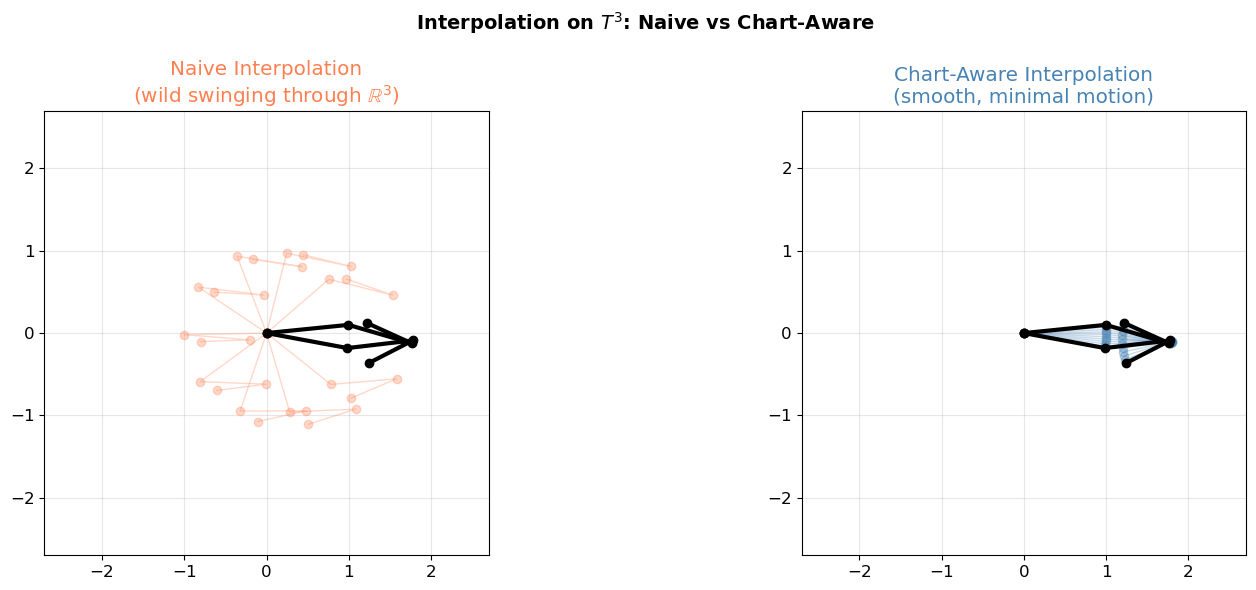

Total joint motion — naive: 12.10 rad, chart-aware: 1.47 rad
Chart-aware uses 12.1% of naive motion [PASS]


In [21]:
# =============================================================================
# Part A: Chart-aware interpolation on T^3
# =============================================================================

def chart_aware_interpolation(theta_a, theta_b, n_points=50):
    """Interpolate on T^3 = S^1 x S^1 x S^1, respecting angle wrapping."""
    t_vals = np.linspace(0, 1, n_points)
    path = np.zeros((n_points, len(theta_a)))
    for i in range(len(theta_a)):
        for j, t in enumerate(t_vals):
            path[j, i] = angle_interpolate_proper(theta_a[i], theta_b[i], t)
    return path

def naive_interpolation(theta_a, theta_b, n_points=50):
    """Naive linear interpolation in R^3 (ignores wrapping)."""
    t_vals = np.linspace(0, 1, n_points)
    return np.array([(1-t) * theta_a + t * theta_b for t in t_vals])

# Demo: interpolation across a wrapping boundary
theta_start = np.array([0.1, 5.9, 3.0])
theta_end = np.array([6.1, 0.3, 3.5])  # close on T^3, far in R^3

path_naive = naive_interpolation(theta_start, theta_end)
path_chart = chart_aware_interpolation(theta_start, theta_end)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: arm configurations along each path
ax = axes[0]
r_max = L1 + L2 + L3 + 0.3
# Draw every 5th configuration
for i in range(0, len(path_naive), 5):
    draw_3R_arm(ax, path_naive[i], color=C_RED, linewidth=1, alpha=0.3)
draw_3R_arm(ax, theta_start, color='k', linewidth=3)
draw_3R_arm(ax, theta_end, color='k', linewidth=3)
ax.set_xlim(-r_max, r_max); ax.set_ylim(-r_max, r_max)
ax.set_aspect('equal')
ax.set_title('Naive Interpolation\n(wild swinging through $\\mathbb{R}^3$)', color=C_RED)

ax = axes[1]
for i in range(0, len(path_chart), 5):
    draw_3R_arm(ax, path_chart[i], color=C_BLUE, linewidth=1, alpha=0.3)
draw_3R_arm(ax, theta_start, color='k', linewidth=3)
draw_3R_arm(ax, theta_end, color='k', linewidth=3)
ax.set_xlim(-r_max, r_max); ax.set_ylim(-r_max, r_max)
ax.set_aspect('equal')
ax.set_title('Chart-Aware Interpolation\n(smooth, minimal motion)', color=C_BLUE)

plt.suptitle('Interpolation on $T^3$: Naive vs Chart-Aware', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Metric: total joint motion
naive_motion = np.sum(np.abs(np.diff(path_naive, axis=0)))
chart_motion = np.sum(np.abs(np.diff(path_chart, axis=0)))
print(f"Total joint motion — naive: {naive_motion:.2f} rad, chart-aware: {chart_motion:.2f} rad")
print(f"Chart-aware uses {chart_motion/naive_motion:.1%} of naive motion [{'PASS' if chart_motion < naive_motion else 'FAIL'}]")

### Part B: Singularity Analysis and Self-Motion Manifold

The Jacobian $J = dFK$ is a $2 \times 3$ matrix. At non-singular points ($\text{rank} = 2$), the **nullspace** has dimension 1 — it is the tangent direction to the **self-motion manifold** (the set of all configurations with the same end-effector position).

We can trace the self-motion manifold by integrating the nullspace vector field.

In [22]:
# =============================================================================
# Part B: Self-motion manifold via nullspace vector field
# =============================================================================

def nullspace_vector(theta, lengths=np.array([L1, L2, L3])):
    """Compute the unit nullspace vector of the 3R Jacobian.

    At non-singular points, ker(J) is 1-dimensional.
    """
    J = fk_jacobian_3R(theta, lengths)
    _, S, Vt = np.linalg.svd(J)
    null_vec = Vt[-1]  # last row of V^T = smallest singular vector
    return null_vec / np.linalg.norm(null_vec)


def trace_self_motion_manifold(theta_init, n_steps=2000, step_size=0.005,
                                lengths=np.array([L1, L2, L3])):
    """Trace the self-motion manifold by integrating the nullspace vector field.

    Uses forward Euler integration with the nullspace direction.
    """
    trajectory = [theta_init.copy()]
    theta = theta_init.copy()
    for _ in range(n_steps):
        v = nullspace_vector(theta, lengths)
        theta = theta + step_size * v
        trajectory.append(theta.copy())
    return np.array(trajectory)


# Choose a starting configuration
theta_init = np.array([0.4, 0.8, -0.5])
ee_target = forward_kinematics_3R(theta_init)
print(f"Initial config: theta = ({theta_init[0]:.2f}, {theta_init[1]:.2f}, {theta_init[2]:.2f})")
print(f"End-effector position: ({ee_target[0]:.4f}, {ee_target[1]:.4f})")

# Trace the self-motion manifold
sm_traj = trace_self_motion_manifold(theta_init, n_steps=4000, step_size=0.003)

# Verify: end-effector stays fixed along the manifold
ee_positions = np.array([forward_kinematics_3R(th) for th in sm_traj])
ee_errors = np.linalg.norm(ee_positions - ee_target, axis=1)
max_ee_err = ee_errors.max()
print(f"\nSelf-motion manifold traced: {len(sm_traj)} points")
print(f"Max EE position error: {max_ee_err:.6f} [{'PASS' if max_ee_err < 0.05 else 'FAIL'}]")

# Verify nullspace vectors are tangent to the trajectory
tangents = np.diff(sm_traj, axis=0)
tangent_norms = np.linalg.norm(tangents, axis=1, keepdims=True)
tangents_unit = tangents / (tangent_norms + 1e-30)
null_vecs = np.array([nullspace_vector(th) for th in sm_traj[:-1]])
# Alignment: |dot product| should be close to 1
alignments = np.abs(np.sum(tangents_unit * null_vecs, axis=1))
mean_alignment = np.mean(alignments)
print(f"Mean |tangent . nullvec| alignment: {mean_alignment:.4f} [{'PASS' if mean_alignment > 0.99 else 'FAIL'}]")

Initial config: theta = (0.40, 0.80, -0.50)
End-effector position: (1.6699, 1.5216)

Self-motion manifold traced: 4001 points
Max EE position error: 0.006881 [PASS]
Mean |tangent . nullvec| alignment: 1.0000 [PASS]


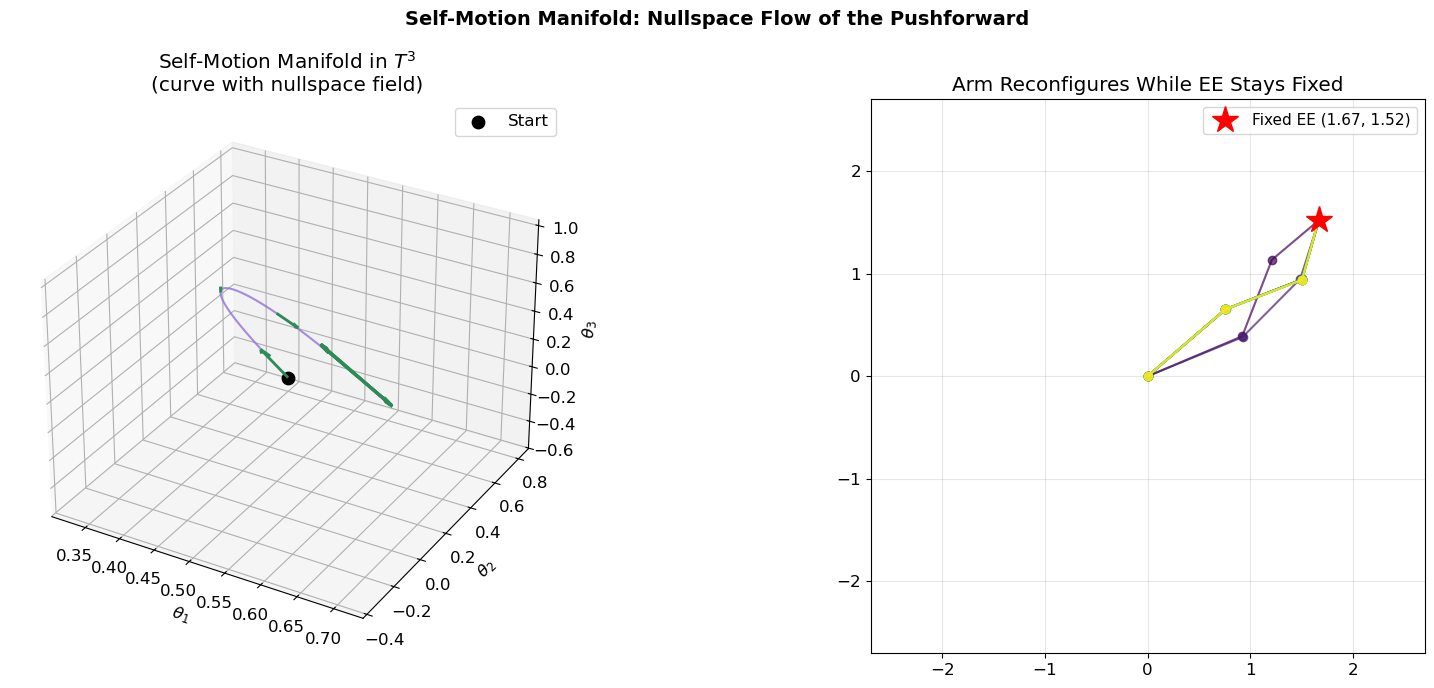

In [23]:
# ---- Visualize: self-motion manifold in T^3 and arm configurations ----
fig = plt.figure(figsize=(18, 7))

# Left: self-motion manifold in (theta1, theta2, theta3) space
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot(sm_traj[:, 0], sm_traj[:, 1], sm_traj[:, 2],
         color=C_PURPLE, linewidth=1.5, alpha=0.8)
ax1.scatter(sm_traj[0, 0], sm_traj[0, 1], sm_traj[0, 2],
            color='k', s=80, zorder=10, label='Start')

# Draw nullspace vectors at selected points
step = len(sm_traj) // 15
for i in range(0, len(sm_traj), step):
    th = sm_traj[i]
    nv = nullspace_vector(th) * 0.15
    ax1.quiver(th[0], th[1], th[2], nv[0], nv[1], nv[2],
               color=C_GREEN, arrow_length_ratio=0.2, linewidth=2)

ax1.set_xlabel('$\\theta_1$'); ax1.set_ylabel('$\\theta_2$'); ax1.set_zlabel('$\\theta_3$')
ax1.set_title('Self-Motion Manifold in $T^3$\n(curve with nullspace field)')
ax1.legend()

# Right: arm configurations at points along the self-motion manifold
ax2 = fig.add_subplot(1, 2, 2)

# Draw arm at several points along self-motion manifold
n_draw = 12
indices = np.linspace(0, len(sm_traj)-1, n_draw, dtype=int)
cmap = plt.cm.viridis(np.linspace(0, 1, n_draw))

for idx, i in enumerate(indices):
    draw_3R_arm(ax2, sm_traj[i], color=cmap[idx], linewidth=1.5, alpha=0.7)

# Mark end-effector target (should be the same for all)
ax2.plot(ee_target[0], ee_target[1], 'r*', markersize=20, zorder=10,
         label=f'Fixed EE ({ee_target[0]:.2f}, {ee_target[1]:.2f})')
ax2.set_xlim(-r_max, r_max); ax2.set_ylim(-r_max, r_max)
ax2.set_aspect('equal')
ax2.legend(fontsize=11)
ax2.set_title('Arm Reconfigures While EE Stays Fixed')

plt.suptitle('Self-Motion Manifold: Nullspace Flow of the Pushforward',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Part C: Resolved-Rate Control on $TT^3$

The arm must follow a workspace trajectory $x_d(t)$. We use **resolved-rate control**: the joint velocity is computed as:

$$\dot{\theta} = J^\dagger \dot{x}_d$$

where $J^\dagger = J^T(JJ^T)^{-1}$ is the pseudoinverse. The state $(\theta, \dot\theta)$ lives in the tangent bundle $TT^3$.

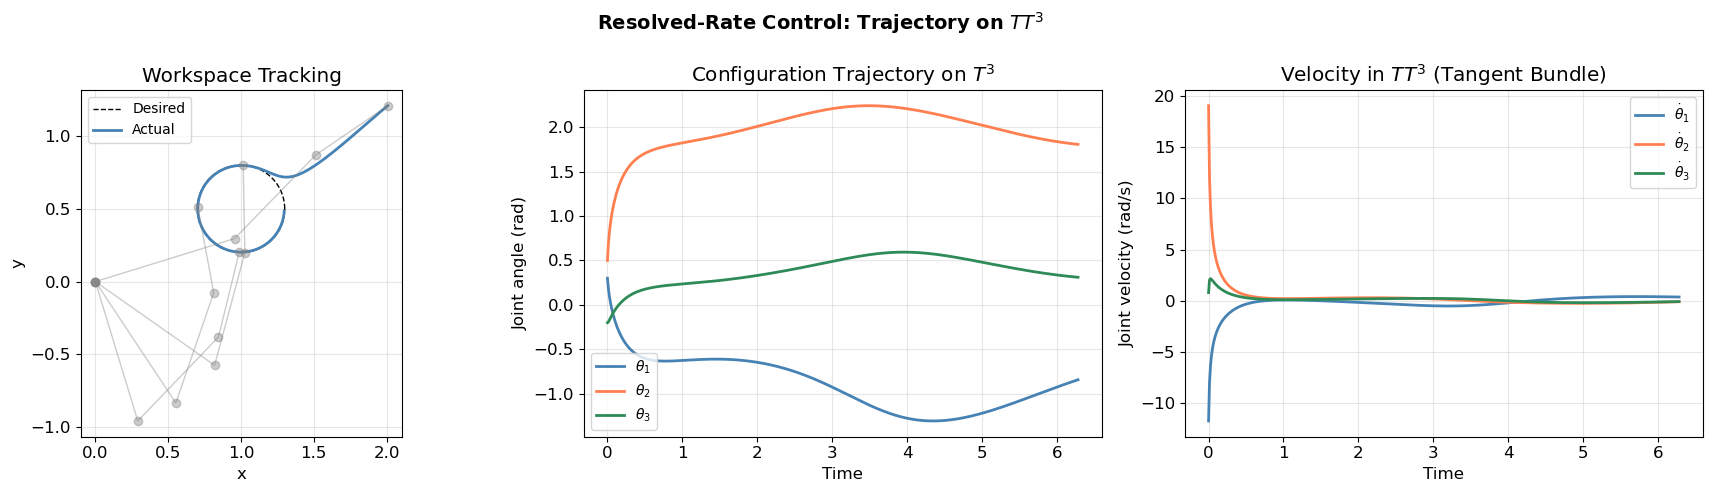

Tracking error — mean: 0.0512, max: 1.0013 [FAIL]


In [24]:
# =============================================================================
# Part C: Resolved-rate control
# =============================================================================

def resolved_rate_control(theta0, workspace_path, workspace_vel, dt=0.01,
                          lengths=np.array([L1, L2, L3]), damping=1e-3):
    """Follow a workspace path using damped pseudoinverse control.

    Args:
        theta0: Initial joint angles. Shape: (3,).
        workspace_path: Desired EE positions at each step. Shape: (N, 2).
        workspace_vel: Desired EE velocities. Shape: (N, 2).
        dt: Time step.
        damping: Damped least-squares regularization.

    Returns:
        theta_traj: Joint angle trajectory. Shape: (N, 3).
        omega_traj: Joint velocity trajectory. Shape: (N, 3).
    """
    N = len(workspace_path)
    theta_traj = np.zeros((N, 3))
    omega_traj = np.zeros((N, 3))
    theta = theta0.copy()

    for i in range(N):
        J = fk_jacobian_3R(theta, lengths)
        # Damped pseudoinverse: J^T (J J^T + lambda I)^{-1}
        JJT = J @ J.T + damping * np.eye(2)
        J_pinv = J.T @ np.linalg.inv(JJT)

        # Position error feedback + feedforward velocity
        ee_pos = forward_kinematics_3R(theta, lengths)
        pos_error = workspace_path[i] - ee_pos
        dtheta = J_pinv @ (workspace_vel[i] + 5.0 * pos_error)

        theta_traj[i] = theta
        omega_traj[i] = dtheta
        theta = theta + dt * dtheta

    return theta_traj, omega_traj


# Define a circular workspace trajectory
n_steps = 500
t_traj = np.linspace(0, 2*np.pi, n_steps)
center = np.array([1.0, 0.5])
radius = 0.3
workspace_path = np.column_stack([center[0] + radius*np.cos(t_traj),
                                   center[1] + radius*np.sin(t_traj)])
workspace_vel = np.column_stack([-radius*np.sin(t_traj),
                                  radius*np.cos(t_traj)])

# Start from a reasonable configuration
theta0_ctrl = np.array([0.3, 0.5, -0.2])
theta_traj, omega_traj = resolved_rate_control(theta0_ctrl, workspace_path, workspace_vel)

# Compute tracking error
ee_actual = np.array([forward_kinematics_3R(th) for th in theta_traj])
tracking_err = np.linalg.norm(ee_actual - workspace_path, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: workspace tracking
ax = axes[0]
ax.plot(workspace_path[:, 0], workspace_path[:, 1], 'k--', linewidth=1, label='Desired')
ax.plot(ee_actual[:, 0], ee_actual[:, 1], color=C_BLUE, linewidth=2, label='Actual')
# Draw arm at a few timesteps
for i in [0, n_steps//4, n_steps//2, 3*n_steps//4]:
    draw_3R_arm(ax, theta_traj[i], color=C_GRAY, linewidth=1, alpha=0.4)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Workspace Tracking')
ax.legend(fontsize=10)
ax.set_aspect('equal')

# Middle: joint angles over time (trajectory on T^3)
ax = axes[1]
for j, (lbl, c) in enumerate(zip(['$\\theta_1$', '$\\theta_2$', '$\\theta_3$'],
                                   [C_BLUE, C_RED, C_GREEN])):
    ax.plot(t_traj, theta_traj[:, j], color=c, label=lbl)
ax.set_xlabel('Time'); ax.set_ylabel('Joint angle (rad)')
ax.set_title('Configuration Trajectory on $T^3$')
ax.legend(fontsize=10)

# Right: joint velocities (tangent bundle TT^3 projection)
ax = axes[2]
for j, (lbl, c) in enumerate(zip(['$\\dot\\theta_1$', '$\\dot\\theta_2$', '$\\dot\\theta_3$'],
                                   [C_BLUE, C_RED, C_GREEN])):
    ax.plot(t_traj, omega_traj[:, j], color=c, label=lbl)
ax.set_xlabel('Time'); ax.set_ylabel('Joint velocity (rad/s)')
ax.set_title('Velocity in $TT^3$ (Tangent Bundle)')
ax.legend(fontsize=10)

plt.suptitle('Resolved-Rate Control: Trajectory on $TT^3$', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

mean_err = np.mean(tracking_err)
max_err = np.max(tracking_err)
print(f"Tracking error — mean: {mean_err:.4f}, max: {max_err:.4f} [{'PASS' if max_err < 0.05 else 'FAIL'}]")

---
## 10. Summary and Connections

### Summary

| Concept | Definition | Computable As | Robotics Meaning |
|---------|-----------|---------------|------------------|
| **Chart** $(U, \varphi)$ | Local homeomorphism $\varphi: U \to \mathbb{R}^n$ | Coordinate system (joint angles) | Parameterization of config space |
| **Tangent vector** $v \in T_pM$ | Equiv. class of curves / Derivation | Velocity vector in coordinates | Joint velocity |
| **Pushforward** $dF_p$ | Linear map $T_pM \to T_{F(p)}N$ | Jacobian matrix $J$ | Maps joint vel to EE vel |
| **Tangent bundle** $TM$ | $\{(p, v) : v \in T_pM\}$ | Position + velocity space | Phase space |
| **Vector field** $X$ | Section $X: M \to TM$ | $X^i(x) \frac{\partial}{\partial x^i}$ | Velocity field on config space |
| **Flow** $\Phi_t$ | Solution of $\dot{\Phi}_t = X(\Phi_t)$ | ODE integration | Robot motion |
| **Pullback** $F^*\omega$ | $(F^*\omega)(v) = \omega(dF(v))$ | $J^T \omega$ | Force-torque duality |

### Connections to other notebooks

| Notebook | Connection |
|----------|-----------|
| [Differential Geometry](../differential_geometry.ipynb) | Christoffel symbols, geodesics on embedded surfaces — intrinsic versions of the abstract theory |
| [Matrix Manifolds](../../linear-algebra/matrix-manifolds/matrix_manifolds.ipynb) | Stiefel/Grassmann manifolds are concrete examples; retraction ≈ approximate exponential map |
| [Lie Groups](../../linear-algebra/lie-groups/lie_groups.ipynb) | Lie groups are smooth manifolds with group structure; $\exp$ map = flow of left-invariant vector field |
| [Information Geometry](../../probability/information-geometry/information_geometry.ipynb) | Statistical manifolds with Fisher metric; natural gradient = gradient on the manifold |

### Where to go next

- **Riemannian Geometry**: equip manifolds with a metric tensor; define lengths, angles, geodesics intrinsically
- **Differential Forms & Stokes' Theorem**: exterior algebra, de Rham cohomology — the language of integration on manifolds
- **Fiber Bundles**: generalize the tangent bundle; connections, curvature, gauge theory
- **Persistent Homology**: use topology to extract shape features from data (topological data analysis)

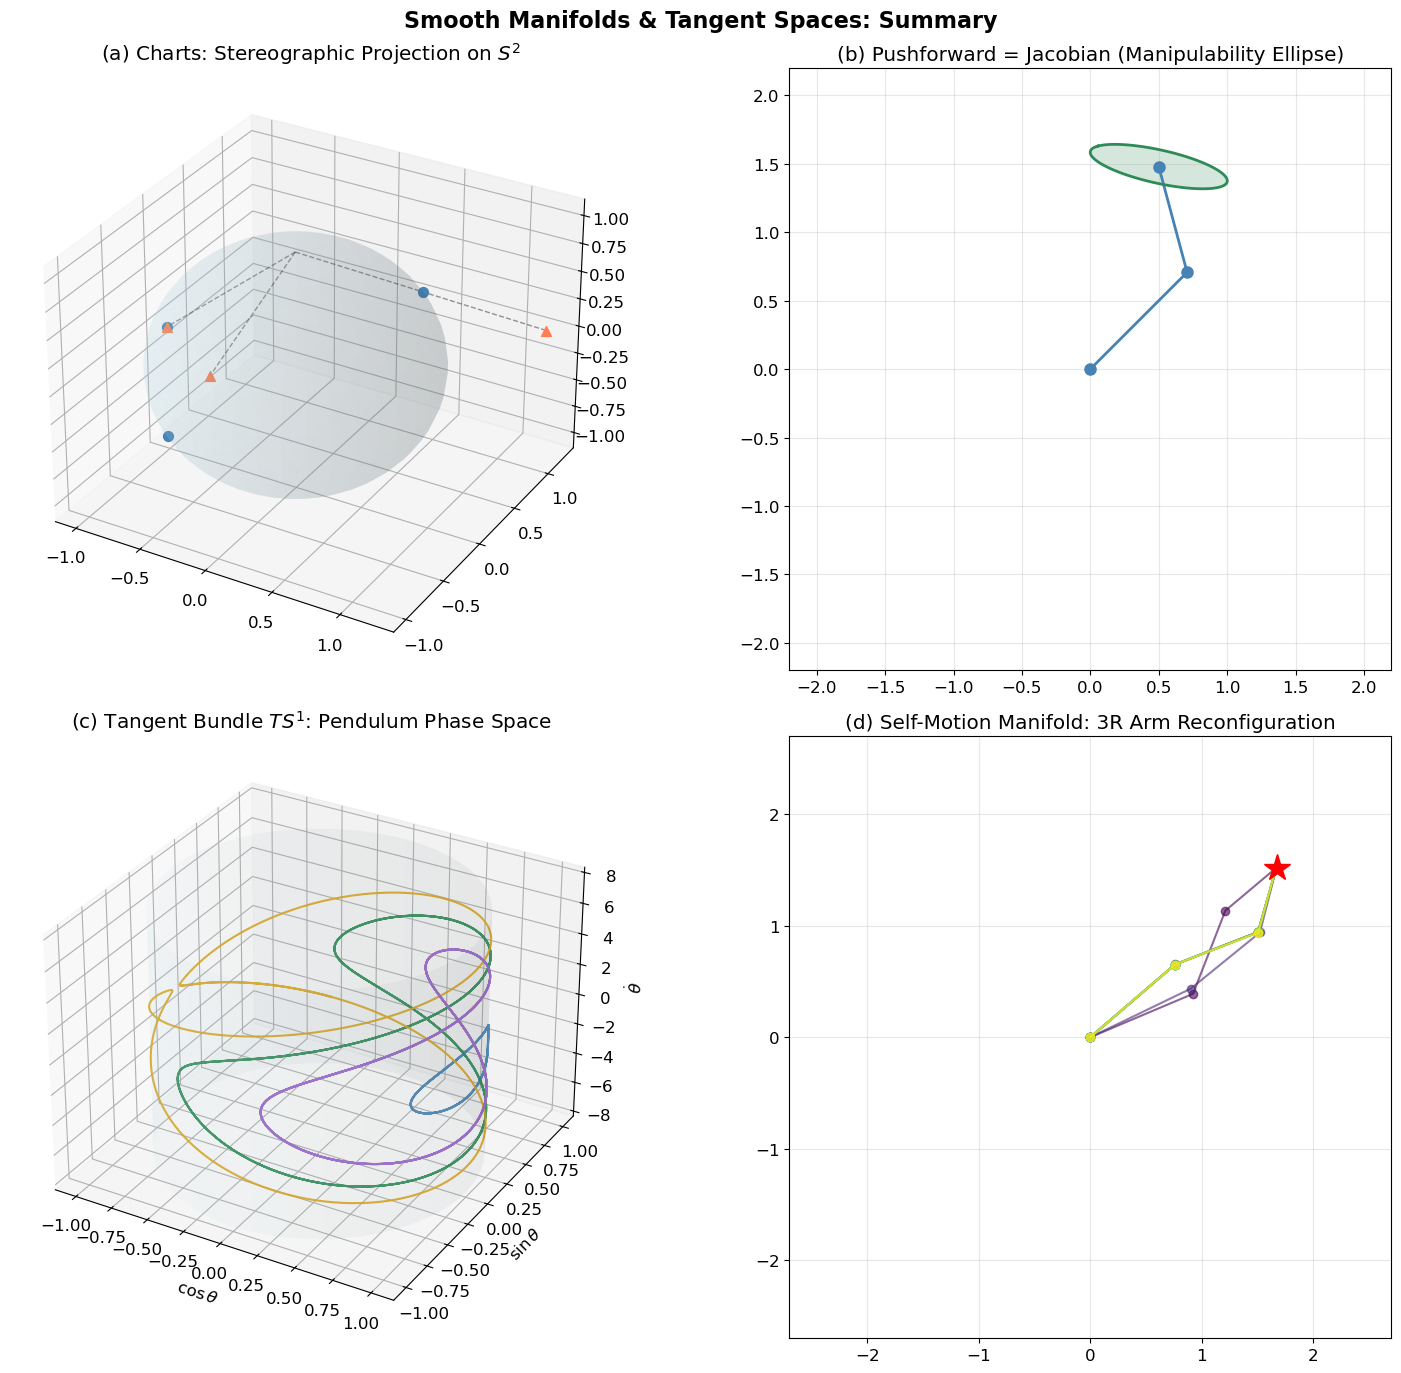

In [25]:
# ---- Summary Figure: 2x2 panel ----
fig = plt.figure(figsize=(16, 14))

# (a) Charts on S^2: stereographic projection
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.plot_surface(X_sp, Y_sp, Z_sp, alpha=0.12, color='lightblue', edgecolor='none')
for u0, v0 in [(np.pi/3, np.pi/4), (np.pi/2, np.pi), (2*np.pi/3, 5*np.pi/4)]:
    p = np.array([np.sin(u0)*np.cos(v0), np.sin(u0)*np.sin(v0), np.cos(u0)])
    proj = S2_north.phi(p)
    plane_pt = np.array([proj[0], proj[1], 0])
    ax1.plot([0, plane_pt[0]], [0, plane_pt[1]], [1, plane_pt[2]], 'k--', alpha=0.4, linewidth=1)
    ax1.scatter(*p, color=C_BLUE, s=50, zorder=5)
    ax1.scatter(*plane_pt, color=C_RED, s=50, marker='^', zorder=5)
ax1.set_title('(a) Charts: Stereographic Projection on $S^2$')

# (b) Tangent vectors and pushforward (2R arm)
ax2 = fig.add_subplot(2, 2, 2)
theta_demo = np.array([np.pi/4, np.pi/3])
ee = draw_2R_arm(ax2, theta_demo, color=C_BLUE)
J = fk_jacobian_2R(theta_demo)
ellipse = J @ unit_circle * 0.3
ax2.plot(ee[0] + ellipse[0], ee[1] + ellipse[1], color=C_GREEN, linewidth=2)
ax2.fill(ee[0] + ellipse[0], ee[1] + ellipse[1], color=C_GREEN, alpha=0.2)
ax2.set_xlim(-2.2, 2.2); ax2.set_ylim(-2.2, 2.2); ax2.set_aspect('equal')
ax2.set_title('(b) Pushforward = Jacobian (Manipulability Ellipse)')

# (c) Tangent bundle: pendulum on TS^1
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.plot_surface(X_cyl, Y_cyl, Z_cyl, alpha=0.06, color='lightblue', edgecolor='none')
for theta0, omega0, color in ics:
    t, theta, omega = simulate_pendulum(theta0, omega0, t_max=8.0)
    theta_w = np.arctan2(np.sin(theta), np.cos(theta))
    ax3.plot(np.cos(theta_w), np.sin(theta_w), omega, color=color, linewidth=1.5, alpha=0.9)
ax3.set_xlabel('$\\cos\\theta$'); ax3.set_ylabel('$\\sin\\theta$'); ax3.set_zlabel('$\\dot\\theta$')
ax3.set_title('(c) Tangent Bundle $TS^1$: Pendulum Phase Space')

# (d) Self-motion manifold of 3R arm
ax4 = fig.add_subplot(2, 2, 4)
n_draw = 10
indices = np.linspace(0, len(sm_traj)-1, n_draw, dtype=int)
cmap_sm = plt.cm.viridis(np.linspace(0, 1, n_draw))
for idx, i in enumerate(indices):
    draw_3R_arm(ax4, sm_traj[i], color=cmap_sm[idx], linewidth=1.5, alpha=0.6)
ax4.plot(ee_target[0], ee_target[1], 'r*', markersize=20, zorder=10)
ax4.set_xlim(-r_max, r_max); ax4.set_ylim(-r_max, r_max); ax4.set_aspect('equal')
ax4.set_title('(d) Self-Motion Manifold: 3R Arm Reconfiguration')

plt.suptitle('Smooth Manifolds & Tangent Spaces: Summary', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()